In [3]:
# ============================================================
# RHINO / limTOD COMPLETE STARTER PIPELINE
# (Works with your HornWet*.fits HEALPix beams)
# ============================================================

import os
import glob
import re
import numpy as np
import healpy as hp
from astropy.io import fits
import matplotlib.pyplot as plt

# ---- limTOD modules (your local files) ----
from limTOD import TODSim
from limTOD import GDSM_sky_model


# ============================================================
# USER SETTINGS
# ============================================================

BEAM_GLOB = "data/HornWet/HornWet*.fits"

# MeerKAT-like site (same as limTOD example)
ANT_LAT = -30.7130
ANT_LON = 21.4430
ANT_H   = 1054

# Drift scan setup
AZIMUTH = 0.0
ELEVATION = 90.0   # zenith drift scan
SELF_ROT = 0.0

# Time sampling
DT = 10.0                     # seconds
N_TIME = 2000                # total samples (~5.5 hrs)

START_TIME = "2019-04-23 20:41:56.397"

# Healpix resolution
BEAM_NSIDE = 512
SKY_NSIDE  = 128
NSIDE_HIRES = 512

# Noise settings (start clean)
WHITE_NOISE_VAR = 1e-10


# ============================================================
# LOAD HEALPIX BEAMS (YOUR FITS FORMAT)
# ============================================================

import glob
import re
import numpy as np
import healpy as hp
from astropy.io import fits

# ------------------------------------------------------------
# 1. Find files
# ------------------------------------------------------------
beam_files = sorted(glob.glob("data/HornWet/HornWet*.fits"))

if len(beam_files) == 0:
    raise RuntimeError("No beam files found. Check path.")

# ------------------------------------------------------------
# 2. Build freq → beam dict
# ------------------------------------------------------------
beam_dict = {}

for f in beam_files:
    freq = float(re.findall(r"\d+\.\d+", f)[0])

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data[0]).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0
    beam /= np.sum(beam)

    beam_dict[freq] = beam

# sorted frequency list
freqs = np.array(sorted(beam_dict.keys()))

print("Loaded freqs:", freqs)


def load_healpix_beam(path):
    """
    Your FITS structure:
    - HDU1: BinTable
    - shape: (3072 rows × 1024 columns)
    → flatten to HEALPix map
    """
    with fits.open(path) as hdul:
        data = hdul[1].data[0]   # one column
        beam = np.array(data).reshape(-1)

    # Check HEALPix consistency
    nside = hp.npix2nside(len(beam))

    # Clean
    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0

    # Normalize (VERY IMPORTANT)
    total = np.sum(beam)
    if total <= 0:
        raise ValueError("Beam has zero total power!")
    beam /= total

    return beam, nside


print("\nLoading beam files...\n")

beam_dict = {}

for path in sorted(glob.glob(BEAM_GLOB)):
    freq = parse_frequency(path)
    beam, nside = load_healpix_beam(path)

    beam_dict[freq] = beam

    print(f"Loaded {freq} MHz | NSIDE={nside}")

freq_list = np.array(sorted(beam_dict.keys()))
print("\nFrequencies:", freq_list)


# ============================================================
# BUILD limTOD BEAM FUNCTION
# ============================================================

def beam_func(*, freq, nside):
    """
    limTOD expects beam_func(freq, nside)
    """
    freqs = np.array(list(beam_dict.keys()))

    # nearest frequency
    f_near = freqs[np.argmin(np.abs(freqs - freq))]
    beam = beam_dict[f_near]

    current_nside = hp.npix2nside(len(beam))

    # upgrade/downgrade if needed
    if current_nside != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    # normalize again after regridding
    beam /= np.sum(beam)

    return beam


# ============================================================
# QUICK BEAM CHECK (CRITICAL STEP)
# ============================================================

print("\nChecking beam visually...\n")

beam_test = beam_func(freq=freq_list[0], nside=BEAM_NSIDE)

hp.mollview(beam_test, title=f"Beam @ {freq_list[0]} MHz")
hp.graticule()
plt.show()


# ============================================================
# SET UP TOD SIMULATOR
# ============================================================

sim = TODSim(
    ant_latitude_deg=ANT_LAT,
    ant_longitude_deg=ANT_LON,
    ant_height_m=ANT_H,
    beam_func=beam_func,
    sky_func=GDSM_sky_model,
    beam_nside=BEAM_NSIDE,
    sky_nside=SKY_NSIDE,
)


# ============================================================
# DEFINE DRIFT SCAN
# ============================================================

time_list = np.arange(N_TIME) * DT
az_list = np.full(N_TIME, AZIMUTH)
selfrot_list = np.full(N_TIME, SELF_ROT)


# ============================================================
# GENERATE TOD
# ============================================================

print("\nSimulating TOD...\n")

overall_TOD, sky_TOD, gain_noise_TOD, LST_deg = sim.generate_TOD(
    freq_list=freq_list,
    time_list=time_list,
    azimuth_deg_list=az_list,
    selfrot_deg_list=selfrot_list,
    elevation_deg=ELEVATION,
    start_time_utc=START_TIME,

    # start simple
    Tsys_others_TOD=None,
    background_gain_TOD=None,
    gain_noise_TOD=0,
    gain_noise_params=None,

    white_noise_var=WHITE_NOISE_VAR,
    return_LSTs=True,
    nside_hires=NSIDE_HIRES,
    normalize_beam=True
)

print("\nTOD shape:", sky_TOD.shape)


# ============================================================
# PLOT: WATERFALL
# ============================================================

plt.figure(figsize=(10,5))

plt.imshow(
    sky_TOD,
    aspect="auto",
    origin="lower",
    extent=[
        time_list[0]/3600,
        time_list[-1]/3600,
        freq_list[0],
        freq_list[-1]
    ]
)

plt.xlabel("Time [hours]")
plt.ylabel("Frequency [MHz]")
plt.title("Drift Scan Waterfall (Sky TOD)")
plt.colorbar(label="Antenna Temperature [K]")

plt.tight_layout()
plt.show()


# ============================================================
# PLOT: ANTENNA TEMP vs LST
# ============================================================

plt.figure(figsize=(10,5))

for i in range(0, len(freq_list), max(1, len(freq_list)//6)):
    plt.plot(LST_deg/15.0, sky_TOD[i], label=f"{freq_list[i]:.1f} MHz")

plt.xlabel("LST [hours]")
plt.ylabel("Antenna Temperature [K]")
plt.title("Drift Scan Signal vs LST")

plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ============================================================
# SAVE OUTPUT
# ============================================================

np.savez(
    "rhino_drift_scan_output.npz",
    freq_list=freq_list,
    time_list=time_list,
    LST=LST_deg,
    sky_TOD=sky_TOD,
    overall_TOD=overall_TOD,
)

print("\nSaved: rhino_drift_scan_output.npz\n")

RuntimeError: No beam files found. Check path.

beam files: ['../data/HornWet/HornWet55.0.fits', '../data/HornWet/HornWet55.5.fits', '../data/HornWet/HornWet56.0.fits', '../data/HornWet/HornWet56.5.fits', '../data/HornWet/HornWet57.0.fits', '../data/HornWet/HornWet57.5.fits', '../data/HornWet/HornWet58.0.fits', '../data/HornWet/HornWet58.5.fits', '../data/HornWet/HornWet59.0.fits', '../data/HornWet/HornWet59.5.fits', '../data/HornWet/HornWet60.0.fits', '../data/HornWet/HornWet60.5.fits', '../data/HornWet/HornWet61.0.fits', '../data/HornWet/HornWet61.5.fits', '../data/HornWet/HornWet62.0.fits', '../data/HornWet/HornWet62.5.fits', '../data/HornWet/HornWet63.0.fits', '../data/HornWet/HornWet63.5.fits', '../data/HornWet/HornWet64.0.fits', '../data/HornWet/HornWet64.5.fits', '../data/HornWet/HornWet65.0.fits', '../data/HornWet/HornWet65.5.fits', '../data/HornWet/HornWet66.0.fits', '../data/HornWet/HornWet66.5.fits', '../data/HornWet/HornWet67.0.fits', '../data/HornWet/HornWet67.5.fits', '../data/HornWet/HornWet68.0.fits', '../data/HornWe

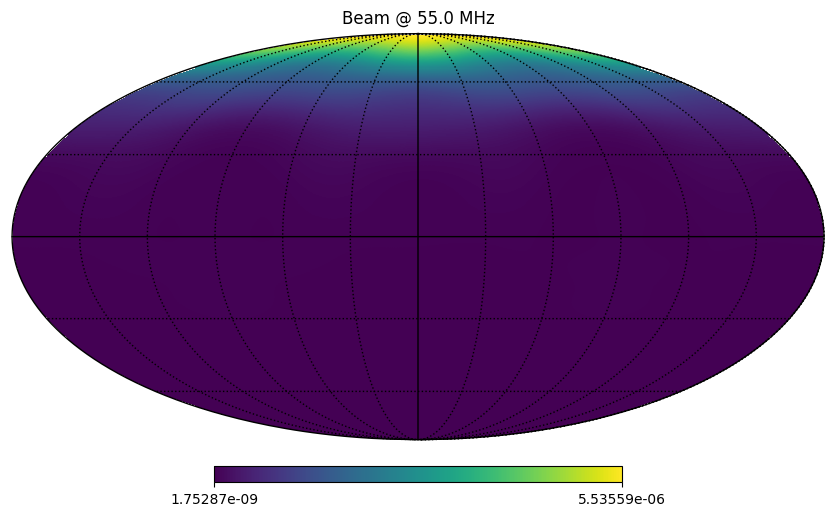

100%|██████████| 2000/2000 [00:14<00:00, 134.09it/s]


TOD shape: (61, 2000)


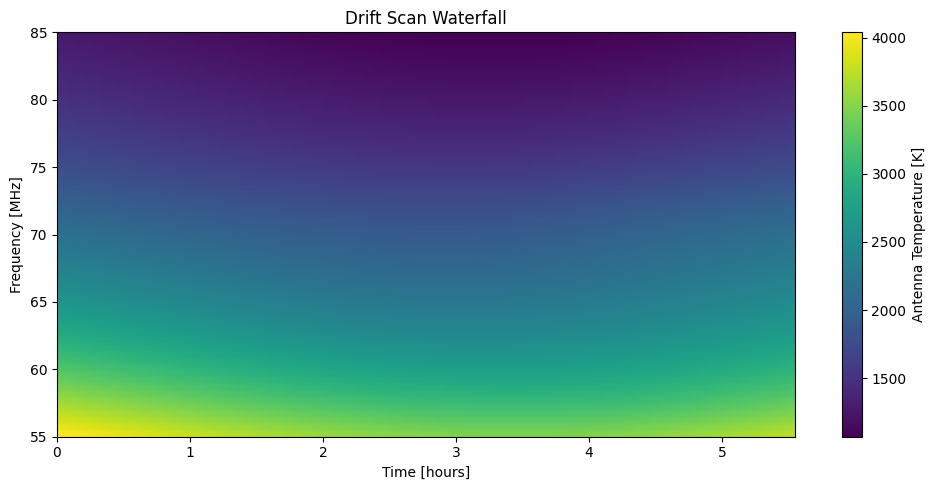

/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_45492/2782782098.py:139: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


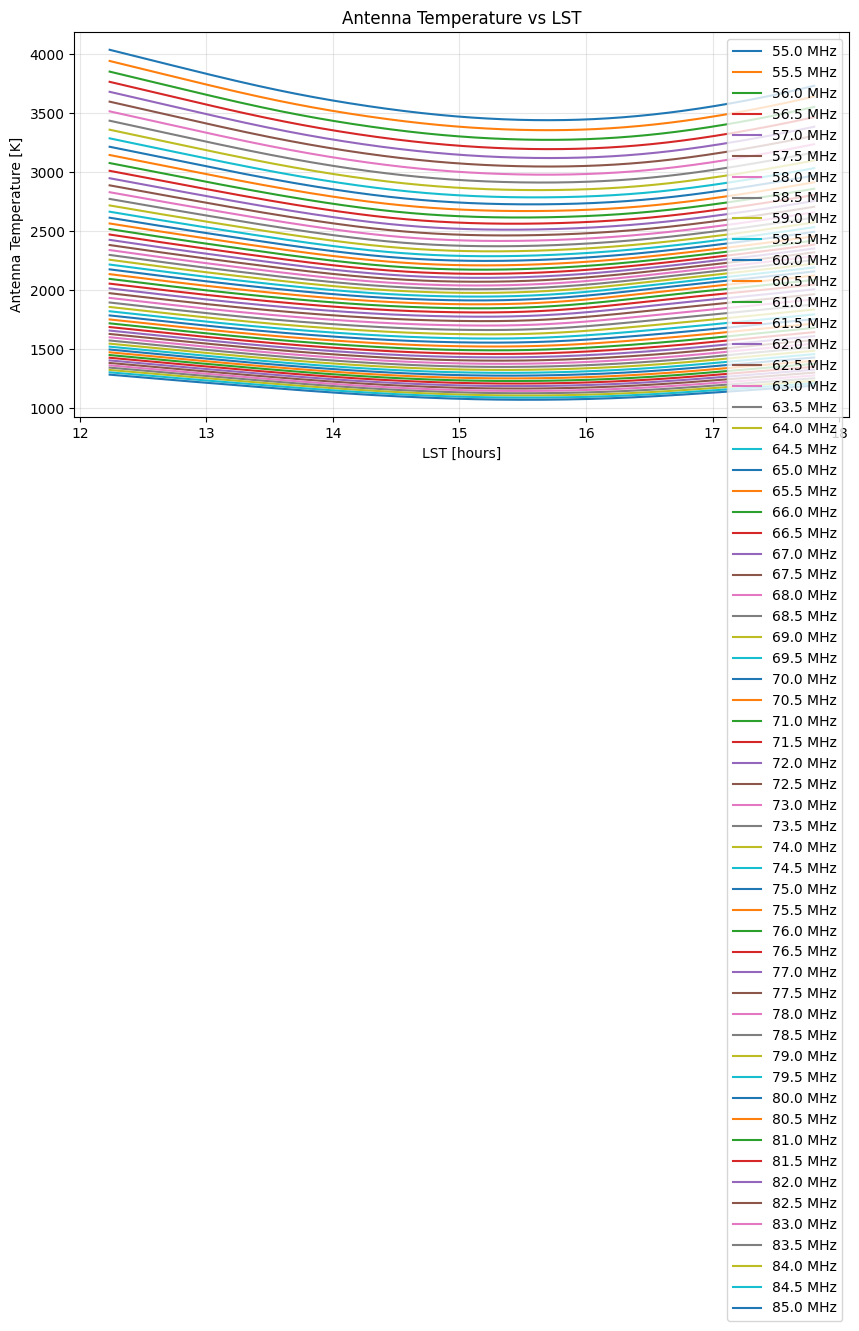

In [ ]:
import glob
import re
import numpy as np
import healpy as hp
from astropy.io import fits
import matplotlib.pyplot as plt

from limTOD import TODSim
from limTOD import GDSM_sky_model

# --------------------------------------------------
# settings
# --------------------------------------------------
BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = -30.7130
ANT_LON = 21.4430
ANT_H   = 1054

AZIMUTH = 0.0
ELEVATION = 90.0
SELF_ROT = 0.0

DT = 10.0
N_TIME = 2000
START_TIME = "2019-04-23 20:41:56.397"

BEAM_NSIDE = 512
SKY_NSIDE = 128
NSIDE_HIRES = 64
WHITE_NOISE_VAR = 1e-10

# --------------------------------------------------
# load beams
# --------------------------------------------------
beam_files = sorted(glob.glob(BEAM_GLOB))
print("beam files:", beam_files)

if not beam_files:
    raise RuntimeError(f"No beam files found for {BEAM_GLOB}")

beam_dict = {}

for f in beam_files:
    freq = float(re.search(r"HornWet([0-9]+(?:\.[0-9]+)?)\.fits$", f).group(1))

    with fits.open(f) as hdul:
        beam = np.asarray(hdul[1].data.field(0), dtype=float).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0
    beam /= beam.sum()

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))
print("Loaded freqs:", freq_list)

# --------------------------------------------------
# limTOD beam function
# --------------------------------------------------
def beam_func(*, freq, nside):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near]

    if hp.npix2nside(len(beam)) != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)
        beam /= beam.sum()

    return beam

# --------------------------------------------------
# quick beam check
# --------------------------------------------------
beam_test = beam_func(freq=freq_list[0], nside=BEAM_NSIDE)
hp.mollview(10 * np.log10(beam_test), title=f"Beam @ {freq_list[0]:.1f} MHz")
hp.graticule()
plt.show()

# --------------------------------------------------
# simulator
# --------------------------------------------------
sim = TODSim(
    ant_latitude_deg=ANT_LAT,
    ant_longitude_deg=ANT_LON,
    ant_height_m=ANT_H,
    beam_func=beam_func,
    sky_func=GDSM_sky_model,
    beam_nside=BEAM_NSIDE,
    sky_nside=SKY_NSIDE,
)

time_list = np.arange(N_TIME) * DT
az_list = np.full(N_TIME, AZIMUTH)
selfrot_list = np.full(N_TIME, SELF_ROT)

overall_TOD, sky_TOD, gain_noise_TOD, LST_deg = sim.generate_TOD(
    freq_list=freq_list,
    time_list=time_list,
    azimuth_deg_list=az_list,
    selfrot_deg_list=selfrot_list,
    elevation_deg=ELEVATION,
    start_time_utc=START_TIME,
    gain_noise_TOD=0,
    gain_noise_params=None,
    white_noise_var=WHITE_NOISE_VAR,
    return_LSTs=True,
    nside_hires=NSIDE_HIRES,
    normalize_beam=True,
)

print("TOD shape:", sky_TOD.shape)

# --------------------------------------------------
# plots
# --------------------------------------------------
plt.figure(figsize=(10, 5))
plt.imshow(
    sky_TOD,
    aspect="auto",
    origin="lower",
    extent=[time_list[0]/3600, time_list[-1]/3600, freq_list[0], freq_list[-1]],
)
plt.xlabel("Time [hours]")
plt.ylabel("Frequency [MHz]")
plt.title("Drift Scan Waterfall")
plt.colorbar(label="Antenna Temperature [K]")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for i in range(len(freq_list)):
    plt.plot(LST_deg / 15.0, sky_TOD[i], label=f"{freq_list[i]:.1f} MHz")
plt.xlabel("LST [hours]")
plt.ylabel("Antenna Temperature [K]")
plt.title("Antenna Temperature vs LST")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

beam files: ['../data/HornWet/HornWet55.0.fits', '../data/HornWet/HornWet55.5.fits', '../data/HornWet/HornWet56.0.fits', '../data/HornWet/HornWet56.5.fits', '../data/HornWet/HornWet57.0.fits', '../data/HornWet/HornWet57.5.fits', '../data/HornWet/HornWet58.0.fits', '../data/HornWet/HornWet58.5.fits', '../data/HornWet/HornWet59.0.fits', '../data/HornWet/HornWet59.5.fits', '../data/HornWet/HornWet60.0.fits', '../data/HornWet/HornWet60.5.fits', '../data/HornWet/HornWet61.0.fits', '../data/HornWet/HornWet61.5.fits', '../data/HornWet/HornWet62.0.fits', '../data/HornWet/HornWet62.5.fits', '../data/HornWet/HornWet63.0.fits', '../data/HornWet/HornWet63.5.fits', '../data/HornWet/HornWet64.0.fits', '../data/HornWet/HornWet64.5.fits', '../data/HornWet/HornWet65.0.fits', '../data/HornWet/HornWet65.5.fits', '../data/HornWet/HornWet66.0.fits', '../data/HornWet/HornWet66.5.fits', '../data/HornWet/HornWet67.0.fits', '../data/HornWet/HornWet67.5.fits', '../data/HornWet/HornWet68.0.fits', '../data/HornWe

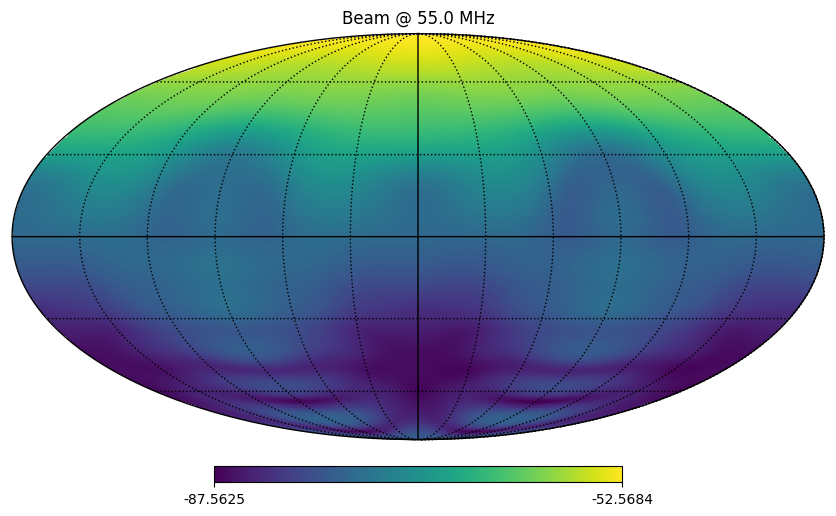

100%|██████████| 2000/2000 [00:14<00:00, 134.88it/s]


TOD shape: (61, 2000)


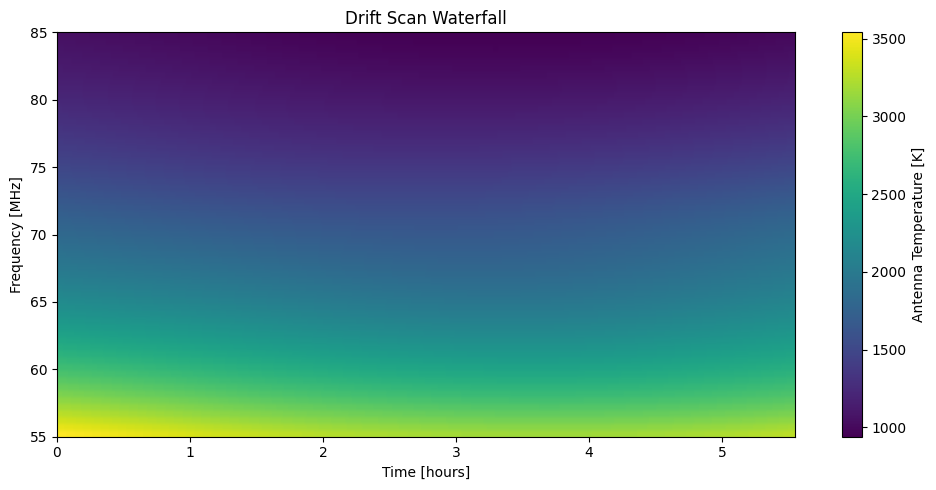

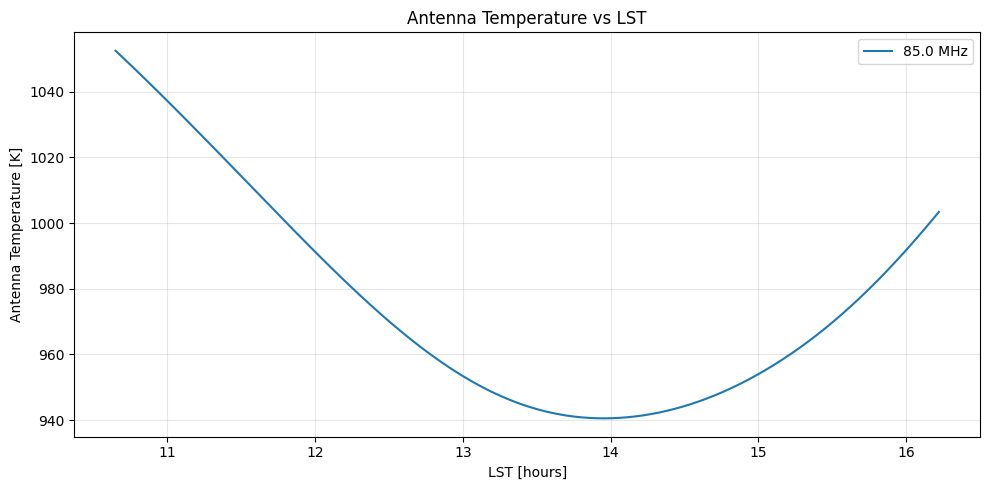

In [6]:
import glob
import re
import numpy as np
import healpy as hp
from astropy.io import fits
import matplotlib.pyplot as plt

from limTOD import TODSim
from limTOD import GDSM_sky_model

# --------------------------------------------------
# settings
# --------------------------------------------------
BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = +53.2421
ANT_LON = -2.3067
ANT_H   = 100

AZIMUTH = 0.0
ELEVATION = 90.0
SELF_ROT = 0.0

DT = 10.0
N_TIME = 2000
START_TIME = "2019-04-23 20:41:56.397"

BEAM_NSIDE = 512
SKY_NSIDE = 128
NSIDE_HIRES = 64
WHITE_NOISE_VAR = 1e-10

# --------------------------------------------------
# load beams
# --------------------------------------------------
beam_files = sorted(glob.glob(BEAM_GLOB))
print("beam files:", beam_files)

if not beam_files:
    raise RuntimeError(f"No beam files found for {BEAM_GLOB}")

beam_dict = {}

for f in beam_files:
    freq = float(re.search(r"HornWet([0-9]+(?:\.[0-9]+)?)\.fits$", f).group(1))

    with fits.open(f) as hdul:
        beam = np.asarray(hdul[1].data.field(0), dtype=float).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0
    beam /= beam.sum()

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))
print("Loaded freqs:", freq_list)

# --------------------------------------------------
# limTOD beam function
# --------------------------------------------------
def beam_func(*, freq, nside):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near]

    if hp.npix2nside(len(beam)) != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)
        beam /= beam.sum()

    return beam

# --------------------------------------------------
# quick beam check
# --------------------------------------------------
beam_test = beam_func(freq=freq_list[0], nside=BEAM_NSIDE)
hp.mollview(10 * np.log10(beam_test), title=f"Beam @ {freq_list[0]:.1f} MHz")
hp.graticule()
plt.show()

# --------------------------------------------------
# simulator
# --------------------------------------------------
sim = TODSim(
    ant_latitude_deg=ANT_LAT,
    ant_longitude_deg=ANT_LON,
    ant_height_m=ANT_H,
    beam_func=beam_func,
    sky_func=GDSM_sky_model,
    beam_nside=BEAM_NSIDE,
    sky_nside=SKY_NSIDE,
)

time_list = np.arange(N_TIME) * DT
az_list = np.full(N_TIME, AZIMUTH)
selfrot_list = np.full(N_TIME, SELF_ROT)

overall_TOD, sky_TOD, gain_noise_TOD, LST_deg = sim.generate_TOD(
    freq_list=freq_list,
    time_list=time_list,
    azimuth_deg_list=az_list,
    selfrot_deg_list=selfrot_list,
    elevation_deg=ELEVATION,
    start_time_utc=START_TIME,
    gain_noise_TOD=0,
    gain_noise_params=None,
    white_noise_var=WHITE_NOISE_VAR,
    return_LSTs=True,
    nside_hires=NSIDE_HIRES,
    normalize_beam=True,
)

print("TOD shape:", sky_TOD.shape)

# --------------------------------------------------
# plots
# --------------------------------------------------
plt.figure(figsize=(10, 5))
plt.imshow(
    sky_TOD,
    aspect="auto",
    origin="lower",
    extent=[time_list[0]/3600, time_list[-1]/3600, freq_list[0], freq_list[-1]],
)
plt.xlabel("Time [hours]")
plt.ylabel("Frequency [MHz]")
plt.title("Drift Scan Waterfall")
plt.colorbar(label="Antenna Temperature [K]")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
# for i in range(len(freq_list)):
plt.plot(LST_deg / 15.0, sky_TOD[i], label=f"{freq_list[i]:.1f} MHz")
plt.xlabel("LST [hours]")
plt.ylabel("Antenna Temperature [K]")
plt.title("Antenna Temperature vs LST")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

beam files: ['../data/HornWet/HornWet55.0.fits', '../data/HornWet/HornWet55.5.fits', '../data/HornWet/HornWet56.0.fits', '../data/HornWet/HornWet56.5.fits', '../data/HornWet/HornWet57.0.fits', '../data/HornWet/HornWet57.5.fits', '../data/HornWet/HornWet58.0.fits', '../data/HornWet/HornWet58.5.fits', '../data/HornWet/HornWet59.0.fits', '../data/HornWet/HornWet59.5.fits', '../data/HornWet/HornWet60.0.fits', '../data/HornWet/HornWet60.5.fits', '../data/HornWet/HornWet61.0.fits', '../data/HornWet/HornWet61.5.fits', '../data/HornWet/HornWet62.0.fits', '../data/HornWet/HornWet62.5.fits', '../data/HornWet/HornWet63.0.fits', '../data/HornWet/HornWet63.5.fits', '../data/HornWet/HornWet64.0.fits', '../data/HornWet/HornWet64.5.fits', '../data/HornWet/HornWet65.0.fits', '../data/HornWet/HornWet65.5.fits', '../data/HornWet/HornWet66.0.fits', '../data/HornWet/HornWet66.5.fits', '../data/HornWet/HornWet67.0.fits', '../data/HornWet/HornWet67.5.fits', '../data/HornWet/HornWet68.0.fits', '../data/HornWe

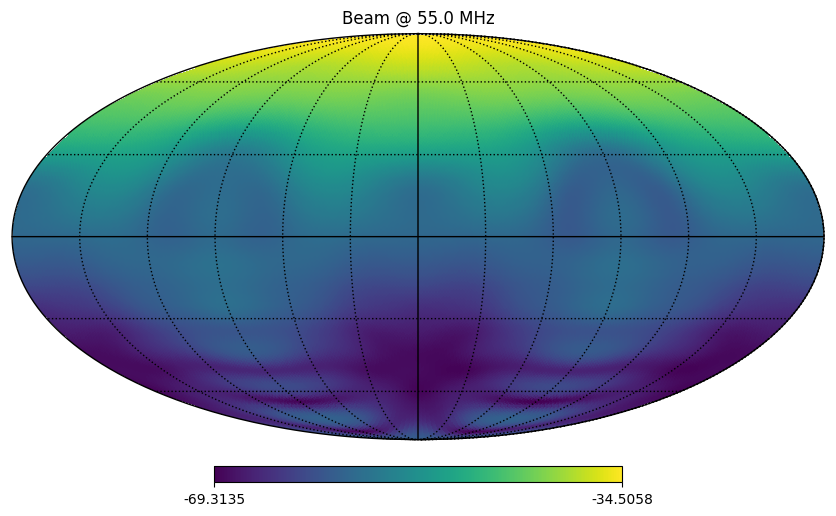

100%|██████████| 2000/2000 [00:12<00:00, 157.73it/s]


TOD shape: (61, 2000)


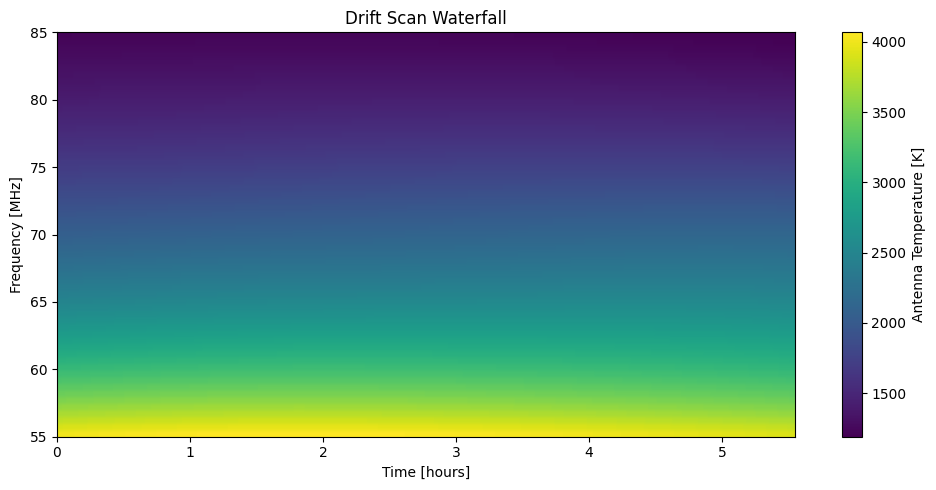

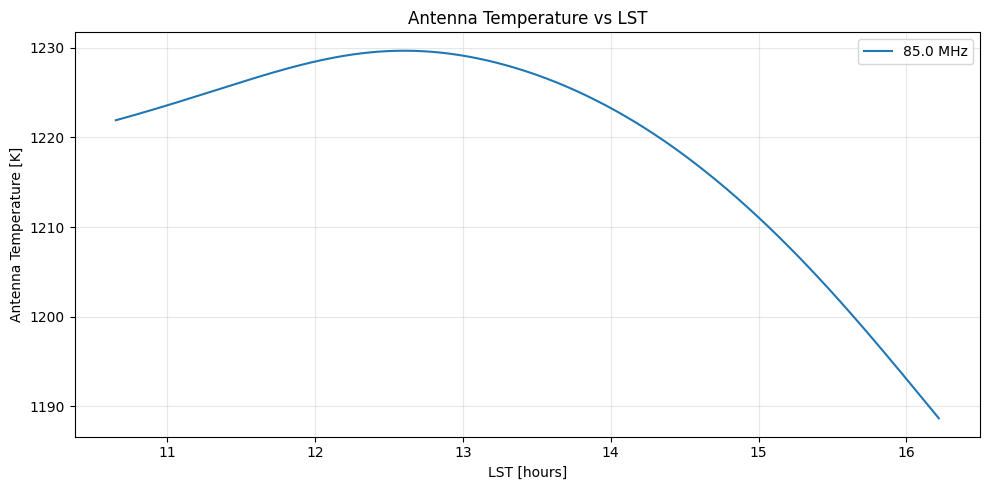

In [7]:
import glob
import re
import numpy as np
import healpy as hp
from astropy.io import fits
import matplotlib.pyplot as plt

from limTOD import TODSim
from limTOD import GDSM_sky_model

# --------------------------------------------------
# settings
# --------------------------------------------------
BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = +53.2421
ANT_LON = -2.3067
ANT_H   = 100

AZIMUTH = 0.0
ELEVATION = 45.0
SELF_ROT = 0.0

DT = 10.0
N_TIME = 2000
START_TIME = "2019-04-23 20:41:56.397"

BEAM_NSIDE = 64
SKY_NSIDE = 64
NSIDE_HIRES = 64
WHITE_NOISE_VAR = 1e-10

# --------------------------------------------------
# load beams
# --------------------------------------------------
beam_files = sorted(glob.glob(BEAM_GLOB))
print("beam files:", beam_files)

if not beam_files:
    raise RuntimeError(f"No beam files found for {BEAM_GLOB}")

beam_dict = {}

for f in beam_files:
    freq = float(re.search(r"HornWet([0-9]+(?:\.[0-9]+)?)\.fits$", f).group(1))

    with fits.open(f) as hdul:
        beam = np.asarray(hdul[1].data.field(0), dtype=float).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0
    beam /= beam.sum()

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))
print("Loaded freqs:", freq_list)

# --------------------------------------------------
# limTOD beam function
# --------------------------------------------------
def beam_func(*, freq, nside):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near]

    if hp.npix2nside(len(beam)) != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)
        beam /= beam.sum()

    return beam

# --------------------------------------------------
# quick beam check
# --------------------------------------------------
beam_test = beam_func(freq=freq_list[0], nside=BEAM_NSIDE)
hp.mollview(10 * np.log10(beam_test), title=f"Beam @ {freq_list[0]:.1f} MHz")
hp.graticule()
plt.show()

# --------------------------------------------------
# simulator
# --------------------------------------------------
sim = TODSim(
    ant_latitude_deg=ANT_LAT,
    ant_longitude_deg=ANT_LON,
    ant_height_m=ANT_H,
    beam_func=beam_func,
    sky_func=GDSM_sky_model,
    beam_nside=BEAM_NSIDE,
    sky_nside=SKY_NSIDE,
)

time_list = np.arange(N_TIME) * DT
az_list = np.full(N_TIME, AZIMUTH)
selfrot_list = np.full(N_TIME, SELF_ROT)

overall_TOD, sky_TOD, gain_noise_TOD, LST_deg = sim.generate_TOD(
    freq_list=freq_list,
    time_list=time_list,
    azimuth_deg_list=az_list,
    selfrot_deg_list=selfrot_list,
    elevation_deg=ELEVATION,
    start_time_utc=START_TIME,
    gain_noise_TOD=0,
    gain_noise_params=None,
    white_noise_var=WHITE_NOISE_VAR,
    return_LSTs=True,
    nside_hires=NSIDE_HIRES,
    normalize_beam=True,
)

print("TOD shape:", sky_TOD.shape)

# --------------------------------------------------
# plots
# --------------------------------------------------
plt.figure(figsize=(10, 5))
plt.imshow(
    sky_TOD,
    aspect="auto",
    origin="lower",
    extent=[time_list[0]/3600, time_list[-1]/3600, freq_list[0], freq_list[-1]],
)
plt.xlabel("Time [hours]")
plt.ylabel("Frequency [MHz]")
plt.title("Drift Scan Waterfall")
plt.colorbar(label="Antenna Temperature [K]")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
# for i in range(len(freq_list)):
plt.plot(LST_deg / 15.0, sky_TOD[i], label=f"{freq_list[i]:.1f} MHz")
plt.xlabel("LST [hours]")
plt.ylabel("Antenna Temperature [K]")
plt.title("Antenna Temperature vs LST")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### With self-rotations

beam files: ['../data/HornWet/HornWet55.0.fits', '../data/HornWet/HornWet55.5.fits', '../data/HornWet/HornWet56.0.fits', '../data/HornWet/HornWet56.5.fits', '../data/HornWet/HornWet57.0.fits', '../data/HornWet/HornWet57.5.fits', '../data/HornWet/HornWet58.0.fits', '../data/HornWet/HornWet58.5.fits', '../data/HornWet/HornWet59.0.fits', '../data/HornWet/HornWet59.5.fits', '../data/HornWet/HornWet60.0.fits', '../data/HornWet/HornWet60.5.fits', '../data/HornWet/HornWet61.0.fits', '../data/HornWet/HornWet61.5.fits', '../data/HornWet/HornWet62.0.fits', '../data/HornWet/HornWet62.5.fits', '../data/HornWet/HornWet63.0.fits', '../data/HornWet/HornWet63.5.fits', '../data/HornWet/HornWet64.0.fits', '../data/HornWet/HornWet64.5.fits', '../data/HornWet/HornWet65.0.fits', '../data/HornWet/HornWet65.5.fits', '../data/HornWet/HornWet66.0.fits', '../data/HornWet/HornWet66.5.fits', '../data/HornWet/HornWet67.0.fits', '../data/HornWet/HornWet67.5.fits', '../data/HornWet/HornWet68.0.fits', '../data/HornWe

100%|██████████| 1200/1200 [00:49<00:00, 24.20it/s]


Running: el90_az0_sr45


100%|██████████| 1200/1200 [00:51<00:00, 23.17it/s]


Running: el90_az0_sr90


...

100%|██████████| 1200/1200 [00:50<00:00, 23.66it/s]


Running: el30_az90_sr90


100%|██████████| 1200/1200 [00:50<00:00, 23.75it/s]


Running: el30_az90_sr180


100%|██████████| 1200/1200 [00:51<00:00, 23.45it/s]


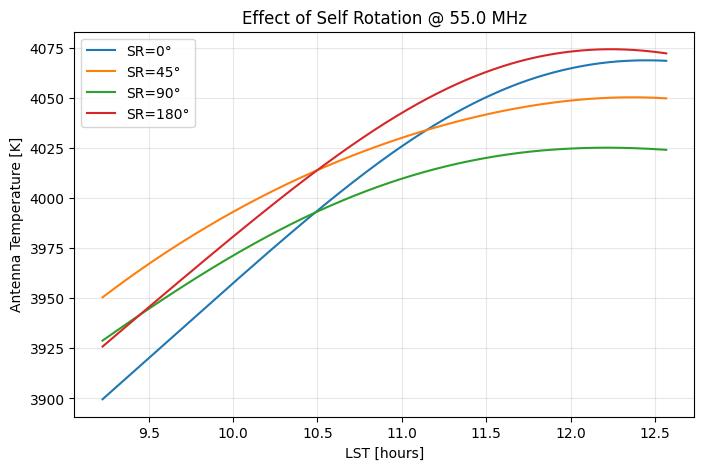

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from limTOD import TODSim
from limTOD import GDSM_sky_model

# --------------------------------------------------
# CONFIG
# --------------------------------------------------
BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100

START_TIME = "2026-04-01 20:41:56.397"

DT = 10.0
N_TIME = 1200

BEAM_NSIDE = 512
SKY_NSIDE = 64
NSIDE_HIRES = 128

WHITE_NOISE_VAR = 1e-10

freq_subset = freq_list[::15]   # reduce for clarity

# parameter grid
elevations = [90, 60, 45, 30]
azimuths   = [0, 90]
selfrots   = [0, 45, 90, 180]

# --------------------------------------------------
# load beams
# --------------------------------------------------
beam_files = sorted(glob.glob(BEAM_GLOB))
print("beam files:", beam_files)

if not beam_files:
    raise RuntimeError(f"No beam files found for {BEAM_GLOB}")

beam_dict = {}

for f in beam_files:
    freq = float(re.search(r"HornWet([0-9]+(?:\.[0-9]+)?)\.fits$", f).group(1))

    with fits.open(f) as hdul:
        beam = np.asarray(hdul[1].data.field(0), dtype=float).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0
    beam /= beam.sum()

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))
print("Loaded freqs:", freq_list)

# --------------------------------------------------
# SIMULATOR
# --------------------------------------------------

sim = TODSim(
    ant_latitude_deg=ANT_LAT,
    ant_longitude_deg=ANT_LON,
    ant_height_m=ANT_H,
    beam_func=beam_func,
    sky_func=GDSM_sky_model,
    beam_nside=BEAM_NSIDE,
    sky_nside=SKY_NSIDE,
)

time_list = np.arange(N_TIME) * DT

results = {}

# --------------------------------------------------
# LOOP
# --------------------------------------------------

for el in elevations:
    for az in azimuths:
        for sr in selfrots:

            key = f"el{el}_az{az}_sr{sr}"
            print("Running:", key)

            az_list = np.full(N_TIME, az)
            sr_list = np.full(N_TIME, sr)

            _, sky_TOD, _, LST = sim.generate_TOD(
                freq_list=freq_subset,
                time_list=time_list,
                azimuth_deg_list=az_list,
                selfrot_deg_list=sr_list,
                elevation_deg=el,
                start_time_utc=START_TIME,
                gain_noise_TOD=0,
                white_noise_var=WHITE_NOISE_VAR,
                return_LSTs=True,
                nside_hires=NSIDE_HIRES,
                normalize_beam=True,
            )

            results[key] = {
                "sky_TOD": sky_TOD,
                "LST": LST
            }

# --------------------------------------------------
# PLOT: effect of self rotation
# --------------------------------------------------

plt.figure(figsize=(8,5))

f_idx = 0   # choose one frequency

for sr in selfrots:
    key = f"el45_az0_sr{sr}"

    plt.plot(
        results[key]["LST"]/15,
        results[key]["sky_TOD"][f_idx],
        label=f"SR={sr}°"
    )

plt.xlabel("LST [hours]")
plt.ylabel("Antenna Temperature [K]")
plt.title(f"Effect of Self Rotation @ {freq_subset[f_idx]:.1f} MHz")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

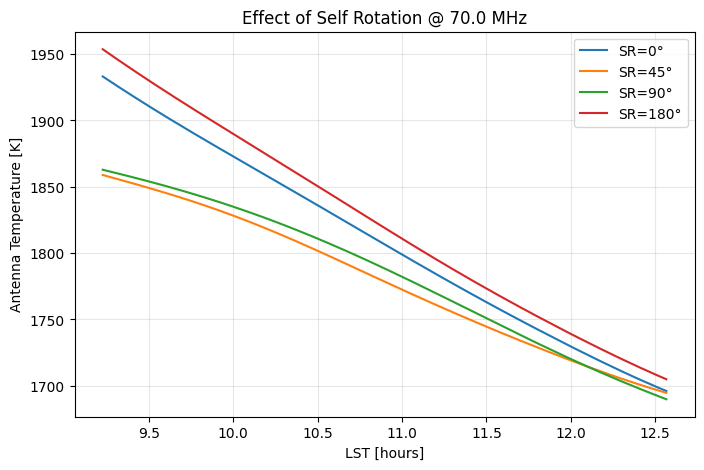

In [15]:
plt.figure(figsize=(8,5))

f_idx = 2   # choose one frequency

for sr in selfrots:
    key = f"el90_az0_sr{sr}"

    plt.plot(
        results[key]["LST"]/15,
        results[key]["sky_TOD"][f_idx],
        label=f"SR={sr}°"
    )

plt.xlabel("LST [hours]")
plt.ylabel("Antenna Temperature [K]")
plt.title(f"Effect of Self Rotation @ {freq_subset[f_idx]:.1f} MHz")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

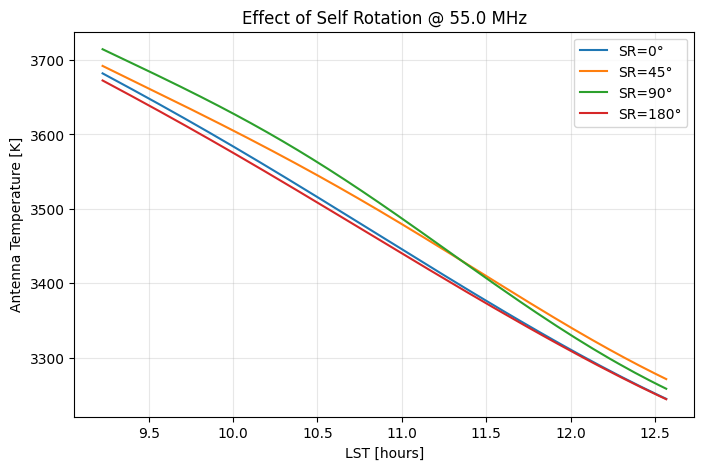

In [13]:
plt.figure(figsize=(8,5))

f_idx = 0   # choose one frequency

for sr in selfrots:
    key = f"el90_az90_sr{sr}"

    plt.plot(
        results[key]["LST"]/15,
        results[key]["sky_TOD"][f_idx],
        label=f"SR={sr}°"
    )

plt.xlabel("LST [hours]")
plt.ylabel("Antenna Temperature [K]")
plt.title(f"Effect of Self Rotation @ {freq_subset[f_idx]:.1f} MHz")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

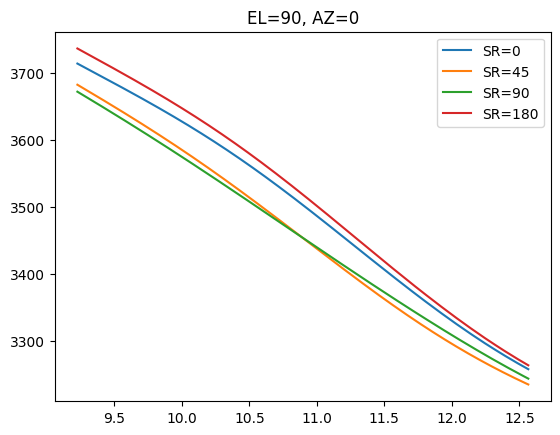

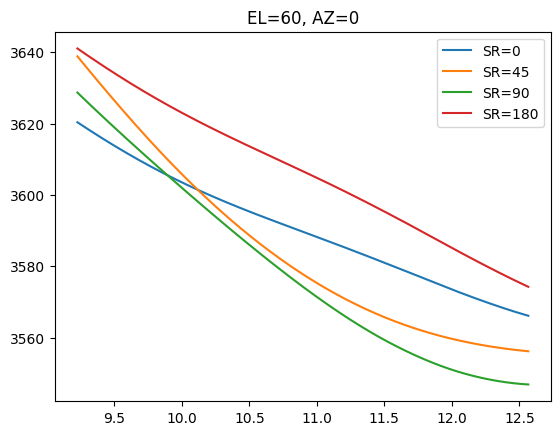

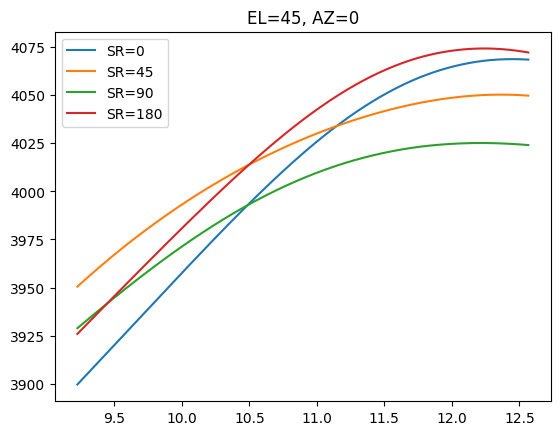

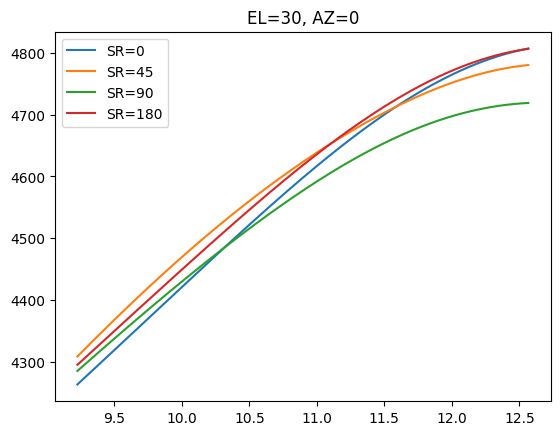

In [16]:
for el in elevations:
    plt.figure()

    for sr in selfrots:
        key = f"el{el}_az0_sr{sr}"

        plt.plot(
            results[key]["LST"]/15,
            results[key]["sky_TOD"][0],
            label=f"SR={sr}"
        )

    plt.title(f"EL={el}, AZ=0")
    plt.legend()
    plt.show()

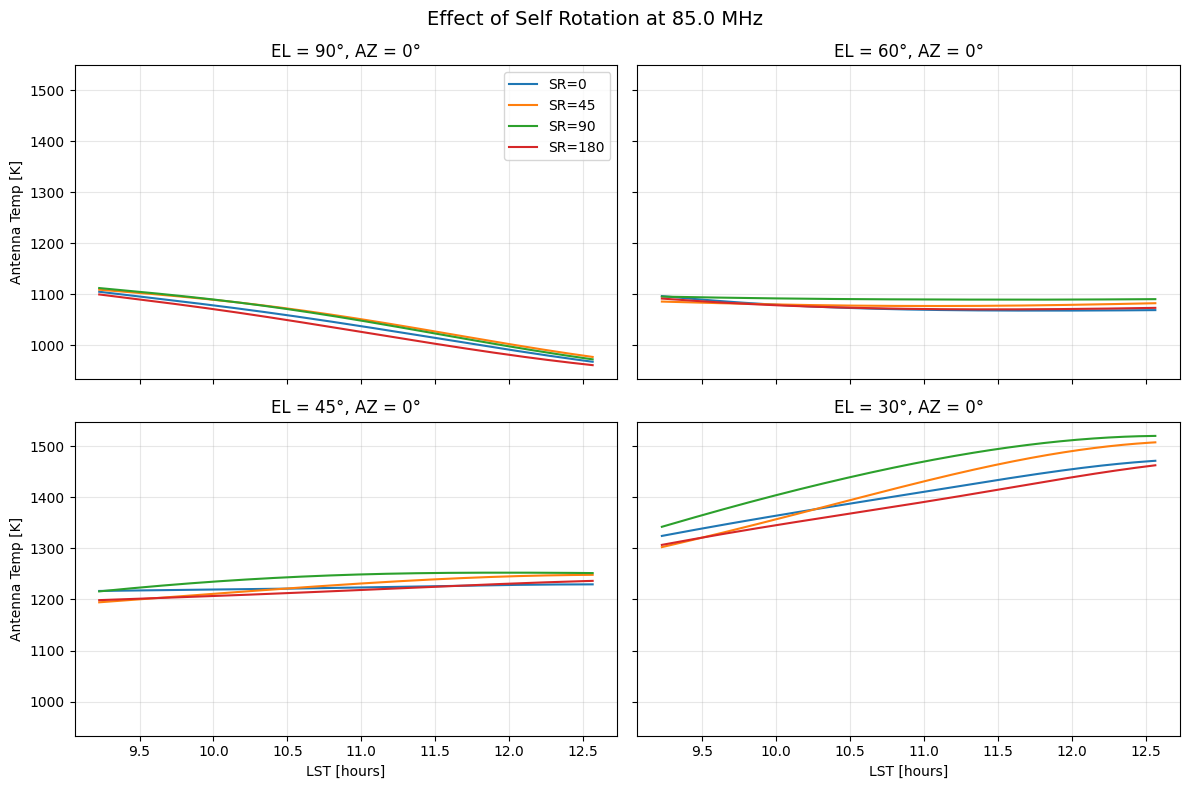

In [17]:
import matplotlib.pyplot as plt

f_idx = 4  # choose one frequency

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, el in enumerate(elevations):
    ax = axes[i]

    for sr in selfrots:
        key = f"el{el}_az0_sr{sr}"

        ax.plot(
            results[key]["LST"]/15,
            results[key]["sky_TOD"][f_idx],
            label=f"SR={sr}"
        )

    ax.set_title(f"EL = {el}°, AZ = 0°")
    ax.grid(alpha=0.3)

    if i in [2, 3]:
        ax.set_xlabel("LST [hours]")
    if i in [0, 2]:
        ax.set_ylabel("Antenna Temp [K]")

# legend only once
axes[0].legend()

plt.suptitle(f"Effect of Self Rotation at {freq_subset[f_idx]:.1f} MHz", fontsize=14)
plt.tight_layout()
plt.show()

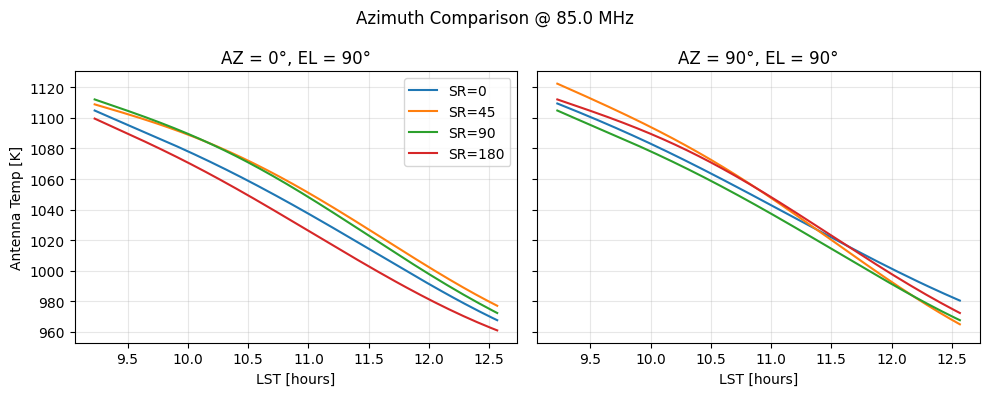

In [18]:
fig, axes = plt.subplots(1, len(azimuths), figsize=(10, 4), sharey=True)

for i, az in enumerate(azimuths):
    ax = axes[i]

    for sr in selfrots:
        key = f"el90_az{az}_sr{sr}"

        ax.plot(
            results[key]["LST"]/15,
            results[key]["sky_TOD"][f_idx],
            label=f"SR={sr}"
        )

    ax.set_title(f"AZ = {az}°, EL = 90°")
    ax.set_xlabel("LST [hours]")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Antenna Temp [K]")
axes[0].legend()

plt.suptitle(f"Azimuth Comparison @ {freq_subset[f_idx]:.1f} MHz")
plt.tight_layout()
plt.show()

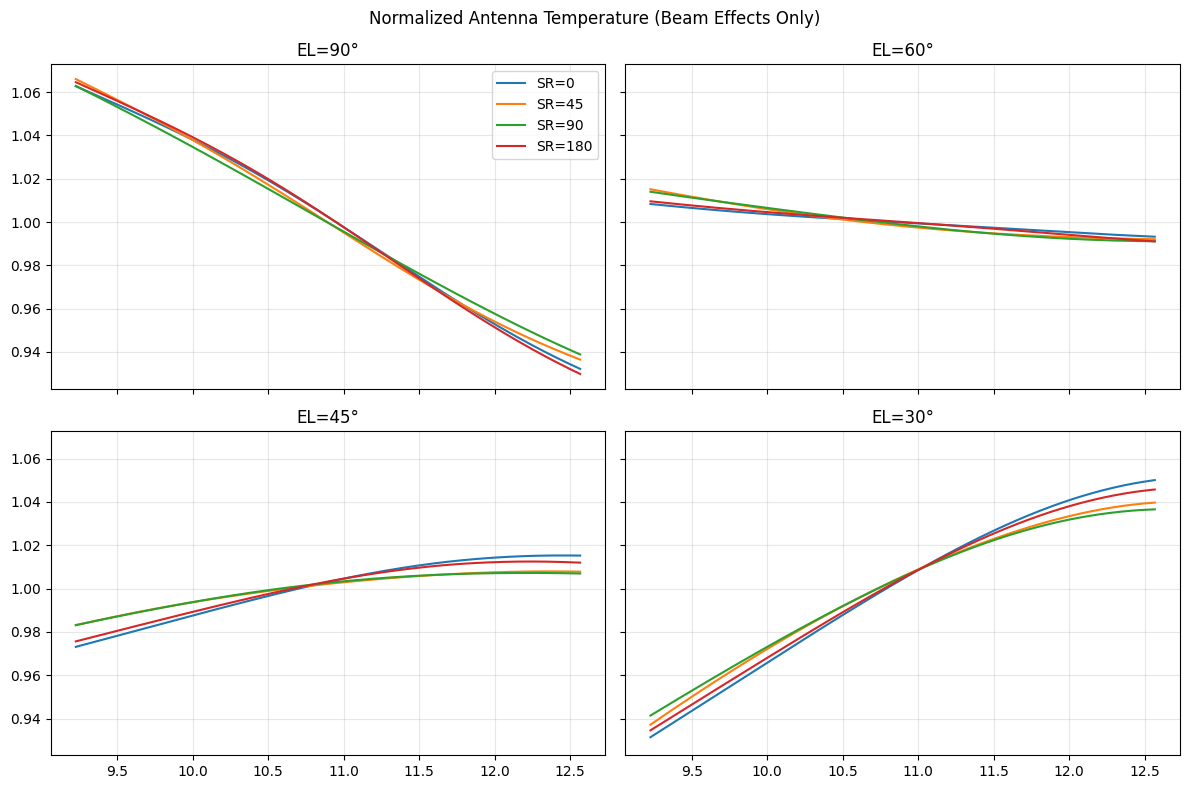

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

f_idx = 0

for i, el in enumerate(elevations):
    ax = axes[i]

    for sr in selfrots:
        key = f"el{el}_az0_sr{sr}"

        T = results[key]["sky_TOD"][f_idx]

        # 🔥 normalize
        T_norm = T / np.mean(T)

        ax.plot(
            results[key]["LST"]/15,
            T_norm,
            label=f"SR={sr}"
        )

    ax.set_title(f"EL={el}°")
    ax.grid(alpha=0.3)

axes[0].legend()
plt.suptitle("Normalized Antenna Temperature (Beam Effects Only)")
plt.tight_layout()
plt.show()

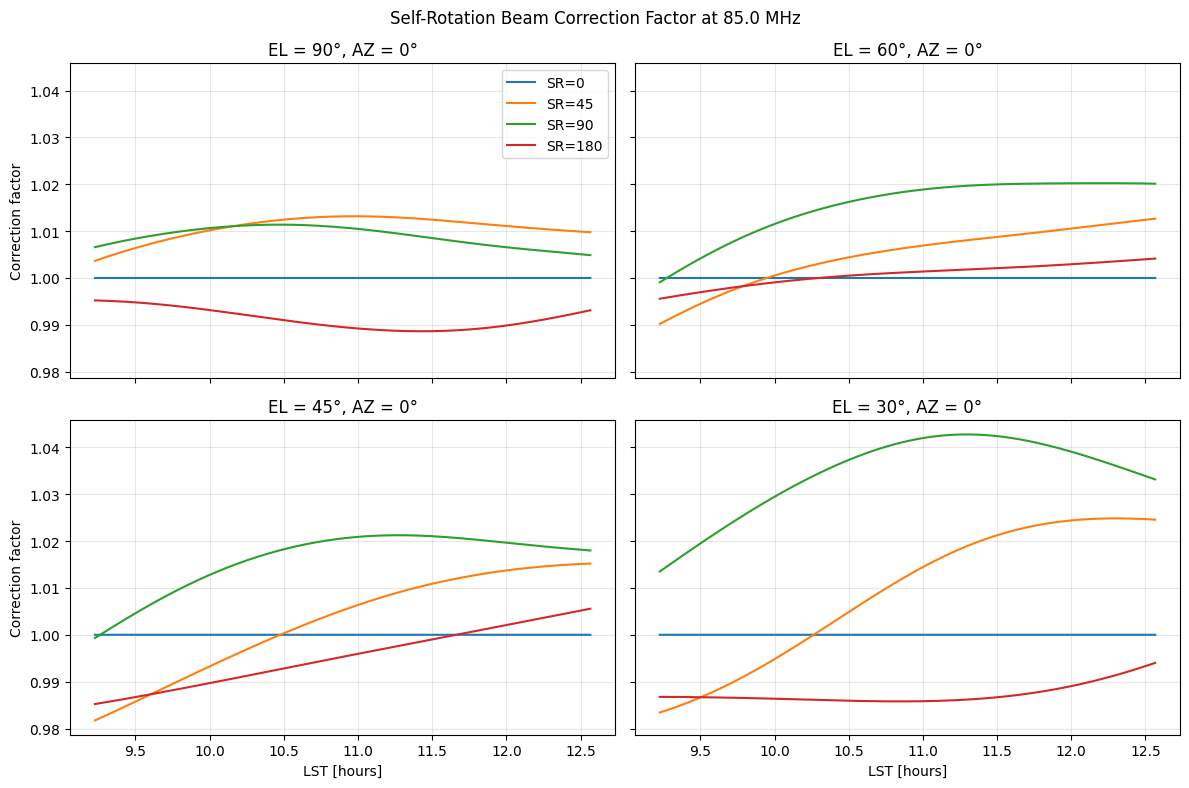

In [20]:
import matplotlib.pyplot as plt
import numpy as np

f_idx = 4  # 85 MHz in your current figure if that's the first/selected channel

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

ref_sr = 0

for i, el in enumerate(elevations):
    ax = axes[i]

    ref_key = f"el{el}_az0_sr{ref_sr}"
    T_ref = results[ref_key]["sky_TOD"][f_idx]
    lst_hours = results[ref_key]["LST"] / 15.0

    for sr in selfrots:
        key = f"el{el}_az0_sr{sr}"
        T = results[key]["sky_TOD"][f_idx]

        corr = T / T_ref   # beam correction factor relative to SR=0

        ax.plot(lst_hours, corr, label=f"SR={sr}")

    ax.set_title(f"EL = {el}°, AZ = 0°")
    ax.grid(alpha=0.3)

    if i in [2, 3]:
        ax.set_xlabel("LST [hours]")
    if i in [0, 2]:
        ax.set_ylabel("Correction factor")

axes[0].legend()
plt.suptitle(f"Self-Rotation Beam Correction Factor at {freq_subset[f_idx]:.1f} MHz")
plt.tight_layout()
plt.show()

### Effect centered around zero

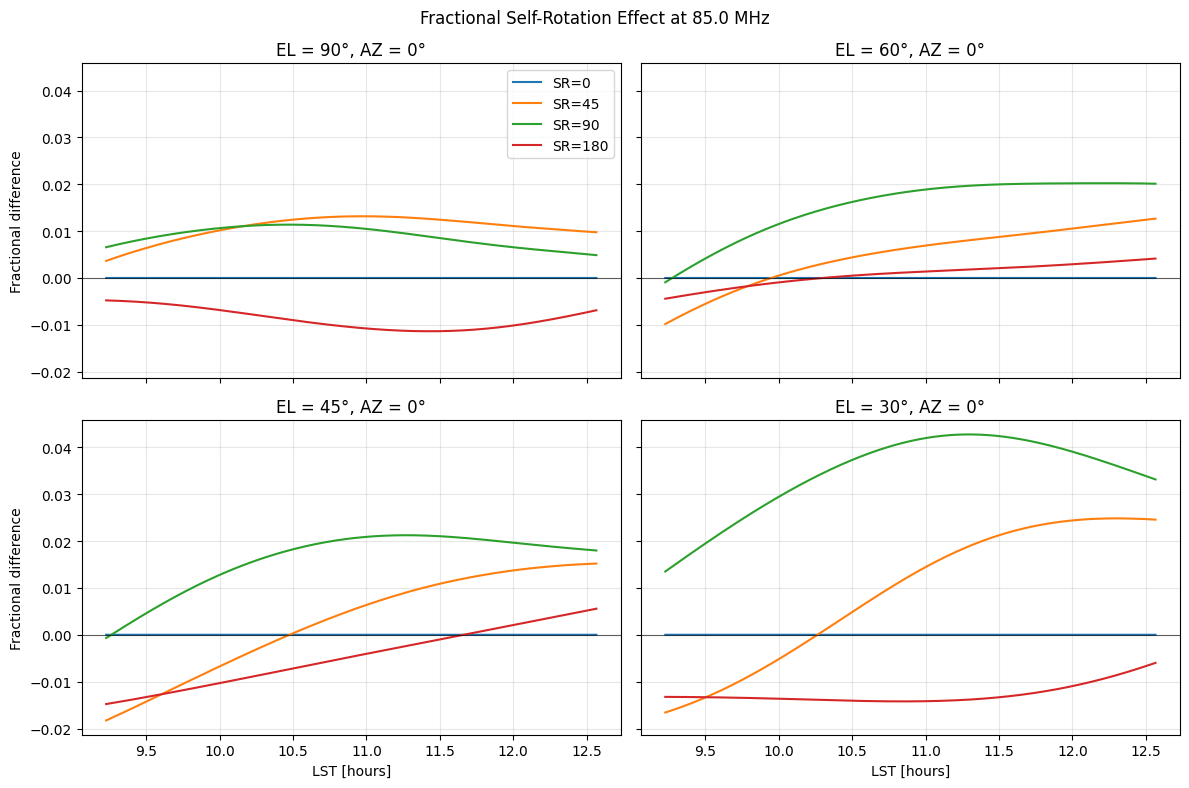

In [22]:
import matplotlib.pyplot as plt
import numpy as np

f_idx = 4
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

ref_sr = 0

for i, el in enumerate(elevations):
    ax = axes[i]

    ref_key = f"el{el}_az0_sr{ref_sr}"
    T_ref = results[ref_key]["sky_TOD"][f_idx]
    lst_hours = results[ref_key]["LST"] / 15.0

    for sr in selfrots:
        key = f"el{el}_az0_sr{sr}"
        T = results[key]["sky_TOD"][f_idx]

        frac = (T - T_ref) / T_ref

        ax.plot(lst_hours, frac, label=f"SR={sr}")

    ax.axhline(0, color="k", lw=0.8, alpha=0.6)
    ax.set_title(f"EL = {el}°, AZ = 0°")
    ax.grid(alpha=0.3)

    if i in [2, 3]:
        ax.set_xlabel("LST [hours]")
    if i in [0, 2]:
        ax.set_ylabel("Fractional difference")

axes[0].legend()
plt.suptitle(f"Fractional Self-Rotation Effect at {freq_subset[f_idx]:.1f} MHz")
plt.tight_layout()
plt.show()

Loaded frequencies: [55.  55.5 56.  56.5 57.  57.5 58.  58.5 59.  59.5 60.  60.5 61.  61.5
 62.  62.5 63.  63.5 64.  64.5 65.  65.5 66.  66.5 67.  67.5 68.  68.5
 69.  69.5 70.  70.5 71.  71.5 72.  72.5 73.  73.5 74.  74.5 75.  75.5
 76.  76.5 77.  77.5 78.  78.5 79.  79.5 80.  80.5 81.  81.5 82.  82.5
 83.  83.5 84.  84.5 85. ]
Using reference frequency: 70.0 MHz
Running self-rotation 0 deg


100%|██████████| 144/144 [00:08<00:00, 17.87it/s]


Running self-rotation 45 deg


100%|██████████| 144/144 [00:07<00:00, 18.58it/s]


Running self-rotation 90 deg


100%|██████████| 144/144 [00:07<00:00, 18.43it/s]


Running self-rotation 180 deg


100%|██████████| 144/144 [00:07<00:00, 18.40it/s]
/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_45492/436238293.py:254: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


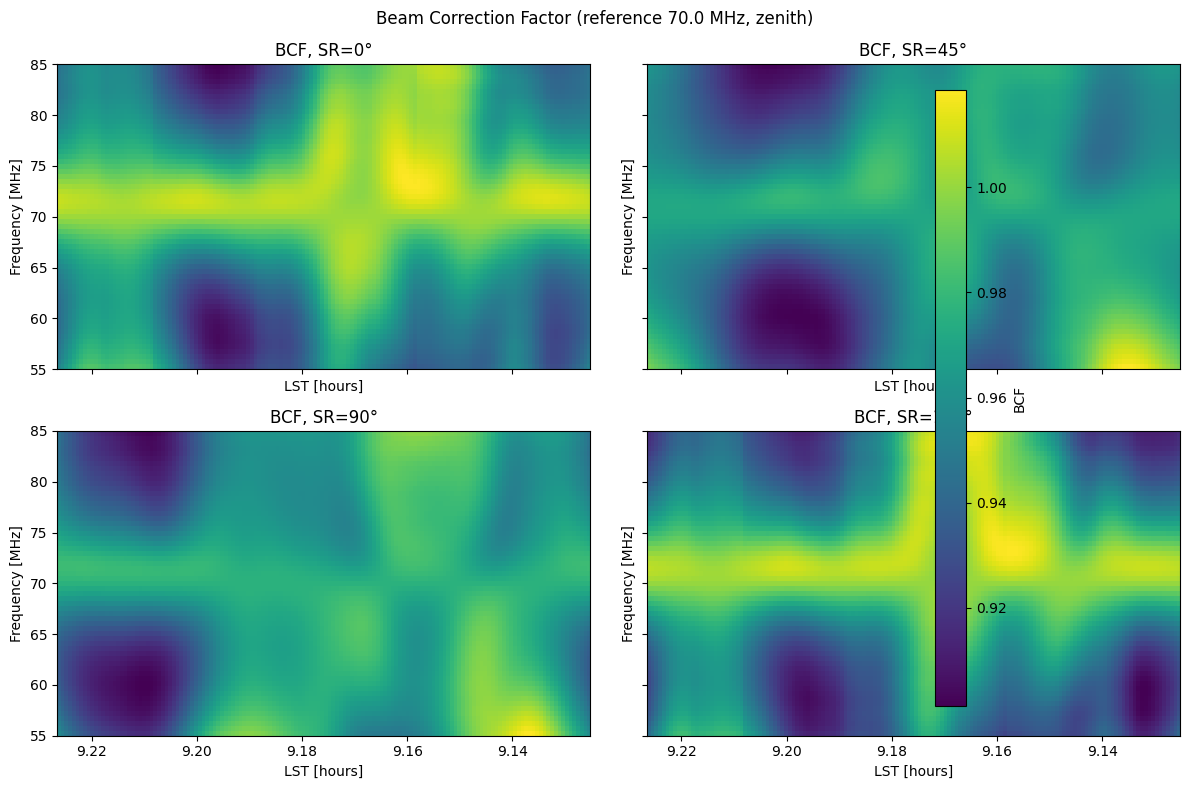

/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_45492/436238293.py:277: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


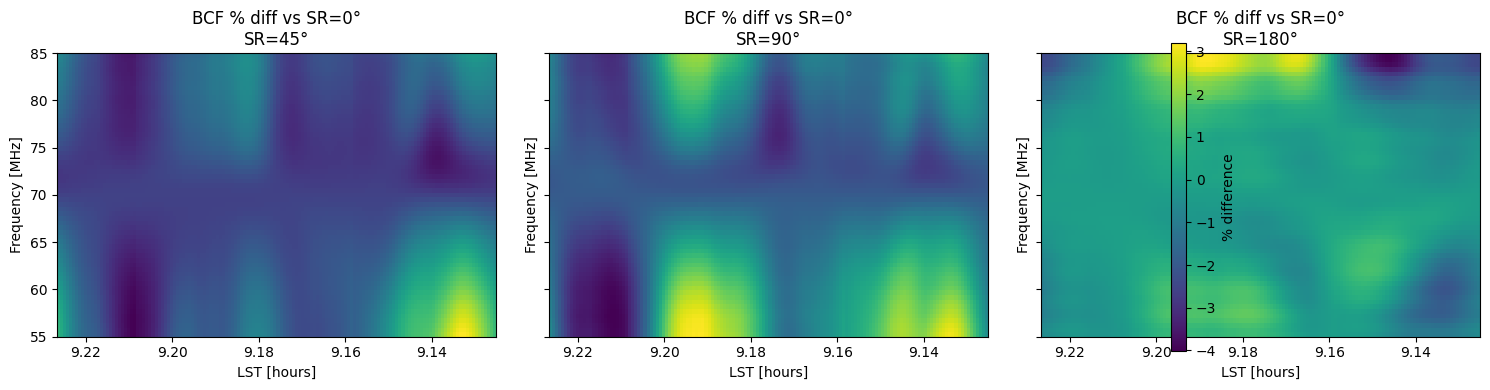

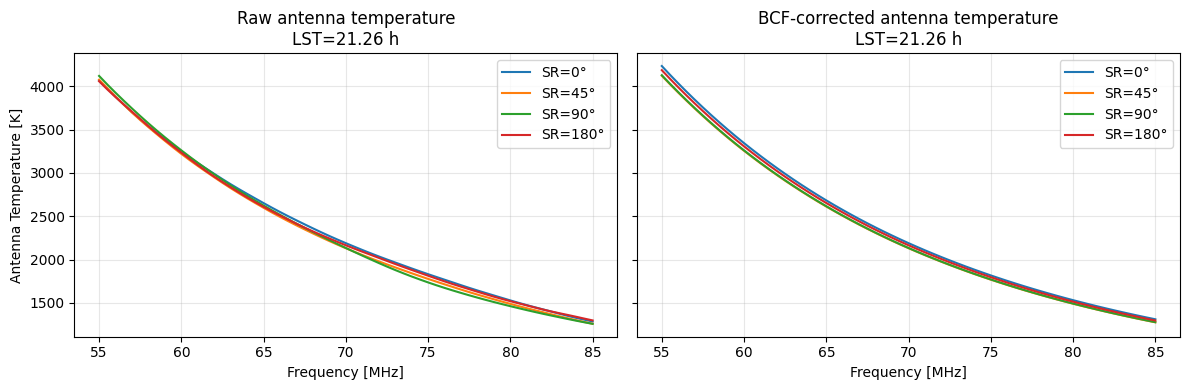

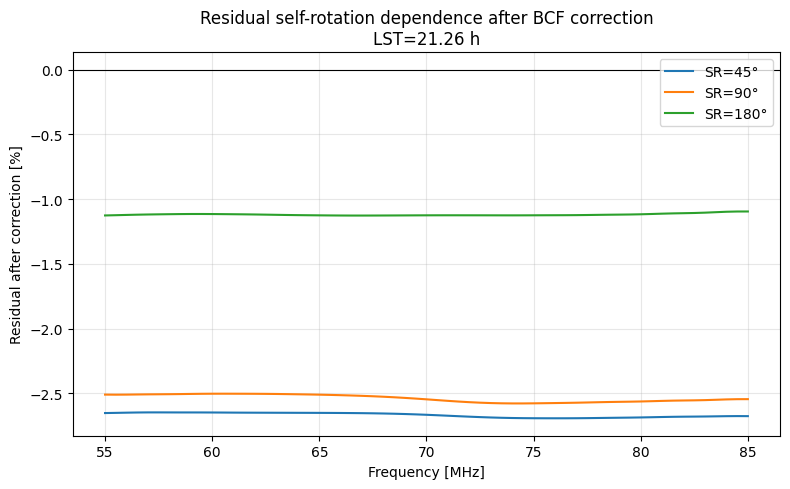

In [23]:
# ============================================================
# ZENITH BCF WITH SELF-ROTATION USING limTOD
# Based on the paper's BCF idea, implemented in map domain
# ============================================================

import glob
import re
import numpy as np
import healpy as hp
from astropy.io import fits
import matplotlib.pyplot as plt

# If you installed limTOD as a package, replace these imports with:
# from limTOD.simulator import TODSim, generate_TOD_sky, generate_LSTs_deg
# from limTOD.sky_model import GDSM_sky_model

from limTOD import TODSim, generate_TOD_sky, generate_LSTs_deg
from limTOD import GDSM_sky_model

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

BEAM_GLOB = "../data/HornWet/HornWet*.fits"   # change if needed

# Site: JBO-ish values you were using
ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100.0

# Zenith-only
AZIMUTH_DEG   = 0.0
ELEVATION_DEG = 90.0

# Self-rotation values to compare
SELFROTS = [0, 45, 90, 180]

# Use a full sidereal day with 10 min cadence, like the paper style
SIDEREAL_DAY_SEC = 23.9344696 * 3600.0
DT_SEC = 600.0
time_list = np.arange(0.0, SIDEREAL_DAY_SEC, DT_SEC)

START_TIME_UTC = "2026-04-01 20:41:56.397"

# Resolution
BEAM_NSIDE  = 512
SKY_NSIDE   = 64
NSIDE_HIRES = 128

# Reference frequency for BCF
REF_FREQ_MHZ = 70.0

# Nearly noiseless
WHITE_NOISE_VAR = 1e-10

# ------------------------------------------------------------
# LOAD HEALPIX BEAMS
# ------------------------------------------------------------

beam_files = sorted(glob.glob(BEAM_GLOB))
if not beam_files:
    raise RuntimeError(f"No beam files found for pattern: {BEAM_GLOB}")

beam_dict = {}

for f in beam_files:
    m = re.search(r"HornWet([0-9]+(?:\.[0-9]+)?)\.fits$", f)
    if m is None:
        continue
    freq = float(m.group(1))

    with fits.open(f) as hdul:
        # Your FITS are binary tables that flatten into a HEALPix map
        beam = np.asarray(hdul[1].data.field(0), dtype=float).reshape(-1)

    beam = np.nan_to_num(beam, nan=0.0, posinf=0.0, neginf=0.0)
    beam[beam < 0] = 0.0

    s = beam.sum()
    if s <= 0:
        raise ValueError(f"Beam sum is zero for {f}")
    beam /= s

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))
if len(freq_list) == 0:
    raise RuntimeError("No frequencies parsed from beam files.")

# Snap reference frequency to nearest available beam frequency
ref_freq = freq_list[np.argmin(np.abs(freq_list - REF_FREQ_MHZ))]
print("Loaded frequencies:", freq_list)
print("Using reference frequency:", ref_freq, "MHz")

def beam_func(*, freq, nside):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near]

    current_nside = hp.npix2nside(len(beam))
    if current_nside != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    beam = np.nan_to_num(beam, nan=0.0, posinf=0.0, neginf=0.0)
    beam[beam < 0] = 0.0

    s = beam.sum()
    if s <= 0:
        raise ValueError(f"Beam sum became zero after ud_grade at {freq} MHz")
    beam /= s

    return beam

# ------------------------------------------------------------
# HORIZON MASK (ABOVE-HORIZON ONLY)
# ------------------------------------------------------------
# In the local horizontal frame, theta <= 90 deg means above horizon.

npix_mask = hp.nside2npix(SKY_NSIDE)
theta_mask, _ = hp.pix2ang(SKY_NSIDE, np.arange(npix_mask))
horizontal_mask = np.zeros(npix_mask)
horizontal_mask[theta_mask <= (np.pi / 2.0)] = 1.0

# ------------------------------------------------------------
# LST / pointing arrays
# ------------------------------------------------------------

LST_deg = generate_LSTs_deg(
    ANT_LAT,
    ANT_LON,
    ANT_H,
    time_list,
    start_time_utc=START_TIME_UTC,
)

az_list = np.full(len(time_list), AZIMUTH_DEG)
el_list = np.full(len(time_list), ELEVATION_DEG)

# ------------------------------------------------------------
# SIMULATOR FOR ACTUAL ANTENNA TEMPERATURE
# ------------------------------------------------------------

sim = TODSim(
    ant_latitude_deg=ANT_LAT,
    ant_longitude_deg=ANT_LON,
    ant_height_m=ANT_H,
    beam_func=beam_func,
    sky_func=GDSM_sky_model,
    beam_nside=BEAM_NSIDE,
    sky_nside=SKY_NSIDE,
)

# ------------------------------------------------------------
# ACTUAL T_ant(nu, t; SR)
# ------------------------------------------------------------

T_ant_by_sr = {}
BCF_by_sr = {}
T_corr_by_sr = {}

for sr in SELFROTS:
    print(f"Running self-rotation {sr} deg")

    sr_list = np.full(len(time_list), sr)

    # Actual antenna temperature using chromatic sky + chromatic beam
    _, sky_TOD, _, _ = sim.generate_TOD(
        freq_list=freq_list,
        time_list=time_list,
        azimuth_deg_list=az_list,
        selfrot_deg_list=sr_list,
        elevation_deg=ELEVATION_DEG,
        start_time_utc=START_TIME_UTC,
        gain_noise_TOD=0,
        gain_noise_params=None,
        white_noise_var=WHITE_NOISE_VAR,
        return_LSTs=True,
        nside_hires=NSIDE_HIRES,
        normalize_beam=True,
        horizontal_mask=horizontal_mask,
    )

    # sky_TOD shape: (nfreq, ntime)
    T_ant_by_sr[sr] = sky_TOD

    # --------------------------------------------------------
    # BCF(nu, t; SR)
    # Use the SAME reference sky map at ref_freq for all nu
    # --------------------------------------------------------

    ref_sky_map = GDSM_sky_model(freq=ref_freq, nside=SKY_NSIDE)

    # Reference-beam observation of the reference sky
    ref_beam = beam_func(freq=ref_freq, nside=BEAM_NSIDE)
    ref_conv = generate_TOD_sky(
        ref_beam,
        ref_sky_map,
        LST_deg,
        ANT_LAT,
        az_list,
        el_list,
        sr_list,
        nside_hires=NSIDE_HIRES,
        normalize_beam=True,
        horizontal_mask=horizontal_mask,
    )  # shape: (ntime,)

    # Each frequency's chromatic beam observing the SAME reference sky
    BCF_cube = np.zeros((len(time_list), len(freq_list)))

    for i, nu in enumerate(freq_list):
        beam_nu = beam_func(freq=nu, nside=BEAM_NSIDE)

        conv_nu = generate_TOD_sky(
            beam_nu,
            ref_sky_map,
            LST_deg,
            ANT_LAT,
            az_list,
            el_list,
            sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True,
            horizontal_mask=horizontal_mask,
        )  # shape: (ntime,)

        BCF_cube[:, i] = conv_nu / ref_conv

    BCF_by_sr[sr] = BCF_cube

    # First-order corrected antenna temperature
    # T_ant shape is (nfreq, ntime), BCF_cube.T is (nfreq, ntime)
    T_corr_by_sr[sr] = T_ant_by_sr[sr] / BCF_cube.T

# ------------------------------------------------------------
# PLOT 1: BCF heatmaps
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, sr in zip(axes, SELFROTS):
    im = ax.imshow(
        BCF_by_sr[sr].T,
        aspect="auto",
        origin="lower",
        extent=[LST_deg[0] / 15.0, LST_deg[-1] / 15.0, freq_list[0], freq_list[-1]],
    )
    ax.set_title(f"BCF, SR={sr}°")
    ax.set_xlabel("LST [hours]")
    ax.set_ylabel("Frequency [MHz]")

fig.colorbar(im, ax=axes.ravel().tolist(), label="BCF")
plt.suptitle(f"Beam Correction Factor (reference {ref_freq:.1f} MHz, zenith)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 2: Percent difference in BCF relative to SR=0
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, sr in zip(axes, [45, 90, 180]):
    pct = 100.0 * (BCF_by_sr[sr] / BCF_by_sr[0] - 1.0)

    im = ax.imshow(
        pct.T,
        aspect="auto",
        origin="lower",
        extent=[LST_deg[0] / 15.0, LST_deg[-1] / 15.0, freq_list[0], freq_list[-1]],
    )
    ax.set_title(f"BCF % diff vs SR=0°\nSR={sr}°")
    ax.set_xlabel("LST [hours]")
    ax.set_ylabel("Frequency [MHz]")

fig.colorbar(im, ax=axes.ravel().tolist(), label="% difference")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 3: Before/after correction at one LST
# ------------------------------------------------------------

# Choose one time index near the middle of the sidereal day
t_idx = len(time_list) // 2
lst_mid = LST_deg[t_idx] / 15.0

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for sr in SELFROTS:
    axes[0].plot(freq_list, T_ant_by_sr[sr][:, t_idx], label=f"SR={sr}°")
axes[0].set_title(f"Raw antenna temperature\nLST={lst_mid:.2f} h")
axes[0].set_xlabel("Frequency [MHz]")
axes[0].set_ylabel("Antenna Temperature [K]")
axes[0].grid(alpha=0.3)
axes[0].legend()

for sr in SELFROTS:
    axes[1].plot(freq_list, T_corr_by_sr[sr][:, t_idx], label=f"SR={sr}°")
axes[1].set_title(f"BCF-corrected antenna temperature\nLST={lst_mid:.2f} h")
axes[1].set_xlabel("Frequency [MHz]")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PLOT 4: Fractional residual after correction relative to SR=0
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 5))

for sr in [45, 90, 180]:
    frac = (T_corr_by_sr[sr][:, t_idx] - T_corr_by_sr[0][:, t_idx]) / T_corr_by_sr[0][:, t_idx]
    ax.plot(freq_list, 100.0 * frac, label=f"SR={sr}°")

ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("Frequency [MHz]")
ax.set_ylabel("Residual after correction [%]")
ax.set_title(f"Residual self-rotation dependence after BCF correction\nLST={lst_mid:.2f} h")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

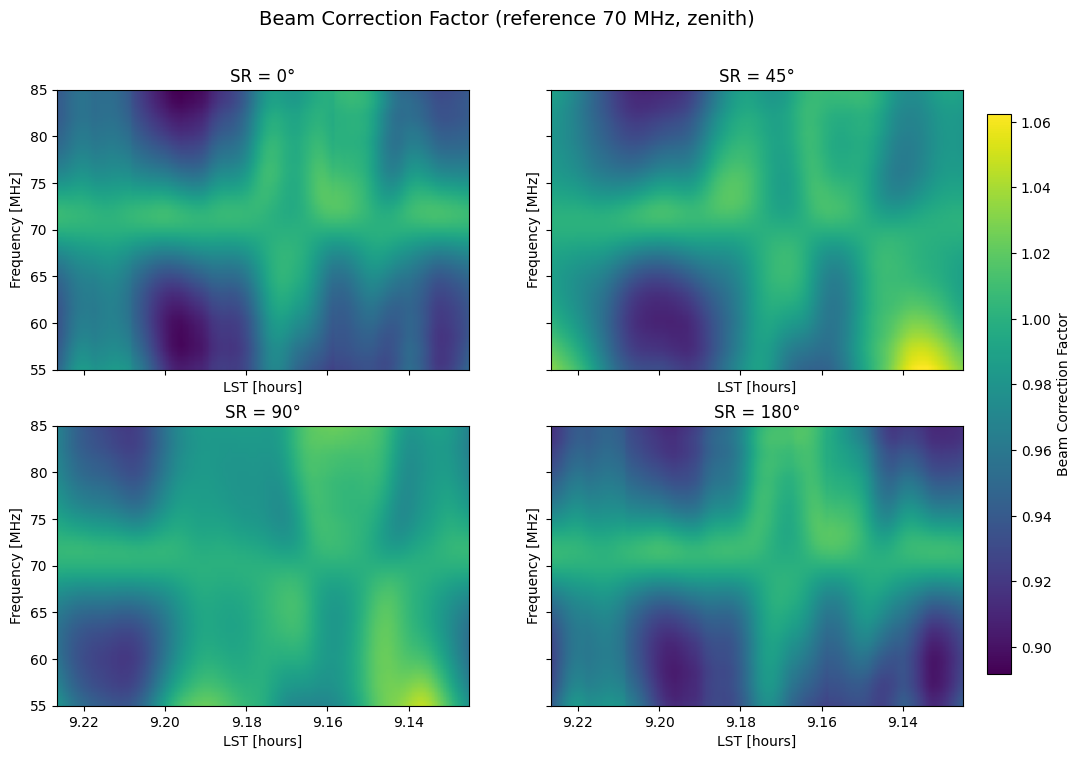

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# DETERMINE COMMON COLOR SCALE (IMPORTANT)
# ------------------------------------------------------------
all_vals = np.concatenate([BCF_by_sr[sr].flatten() for sr in SELFROTS])
vmin = np.min(all_vals)
vmax = np.max(all_vals)

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, sr in zip(axes, SELFROTS):

    im = ax.imshow(
        BCF_by_sr[sr].T,
        aspect="auto",
        origin="lower",
        extent=[
            LST_deg[0] / 15.0,
            LST_deg[-1] / 15.0,
            freq_list[0],
            freq_list[-1]
        ],
        vmin=vmin,   # 🔥 same scale across all panels
        vmax=vmax
    )

    ax.set_title(f"SR = {sr}°")
    ax.set_xlabel("LST [hours]")
    ax.set_ylabel("Frequency [MHz]")
    ax.grid(False)

# ------------------------------------------------------------
# FIX COLORBAR (clean placement)
# ------------------------------------------------------------
plt.subplots_adjust(right=0.88)

cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Beam Correction Factor")

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------
plt.suptitle("Beam Correction Factor (reference 70 MHz, zenith)", fontsize=14)

plt.show()

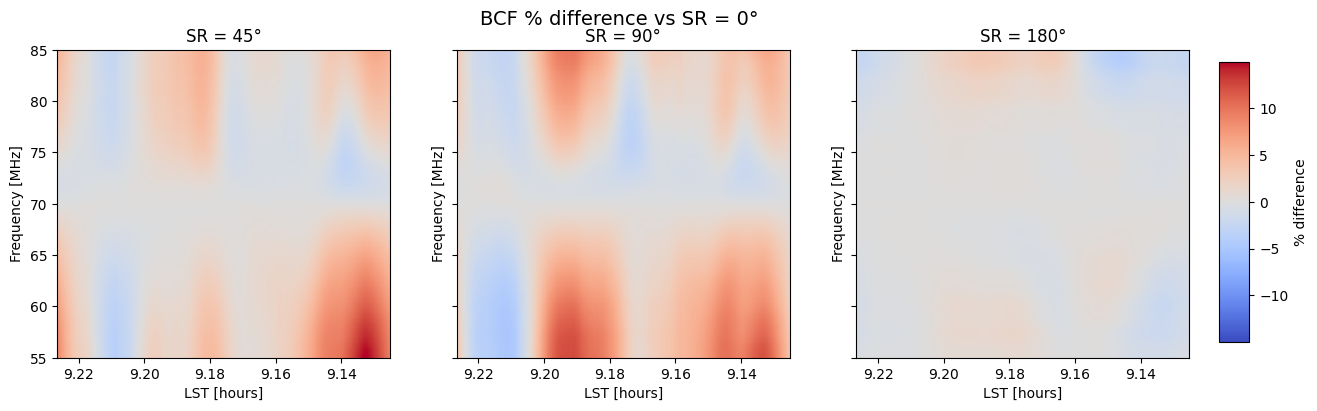

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# CONFIG
# ------------------------------------------------------------
ref_sr = 0
compare_srs = [45, 90, 180]

# reference BCF
BCF_ref = BCF_by_sr[ref_sr]

# ------------------------------------------------------------
# DETERMINE GLOBAL COLOR SCALE (IMPORTANT)
# ------------------------------------------------------------
all_vals = []

for sr in compare_srs:
    frac = (BCF_by_sr[sr] / BCF_ref - 1.0) * 100
    all_vals.append(frac.flatten())

all_vals = np.concatenate(all_vals)

vmin = np.min(all_vals)
vmax = np.max(all_vals)

# optional: symmetric scale (recommended)
vlim = max(abs(vmin), abs(vmax))
vmin, vmax = -vlim, vlim

# ------------------------------------------------------------
# PLOT
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True, sharey=True)

for ax, sr in zip(axes, compare_srs):

    frac = (BCF_by_sr[sr] / BCF_ref - 1.0) * 100

    im = ax.imshow(
        frac.T,
        aspect="auto",
        origin="lower",
        extent=[
            LST_deg[0] / 15.0,
            LST_deg[-1] / 15.0,
            freq_list[0],
            freq_list[-1]
        ],
        cmap="coolwarm",
        vmin=vmin,
        vmax=vmax
    )

    ax.set_title(f"SR = {sr}°")
    ax.set_xlabel("LST [hours]")
    ax.set_ylabel("Frequency [MHz]")

# ------------------------------------------------------------
# COLORBAR (clean placement)
# ------------------------------------------------------------
plt.subplots_adjust(right=0.88)

cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("% difference")

# ------------------------------------------------------------
# TITLE
# ------------------------------------------------------------
plt.suptitle("BCF % difference vs SR = 0°", fontsize=14)

plt.show()

### Different rotation behaviours (messed-up)

Running: constant_0


100%|██████████| 144/144 [00:06<00:00, 23.12it/s]


Running: constant_45


100%|██████████| 144/144 [00:06<00:00, 21.97it/s]


Running: linear_sweep


100%|██████████| 144/144 [00:06<00:00, 23.48it/s]


Running: oscillating


100%|██████████| 144/144 [00:06<00:00, 22.60it/s]
/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_45492/753437276.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


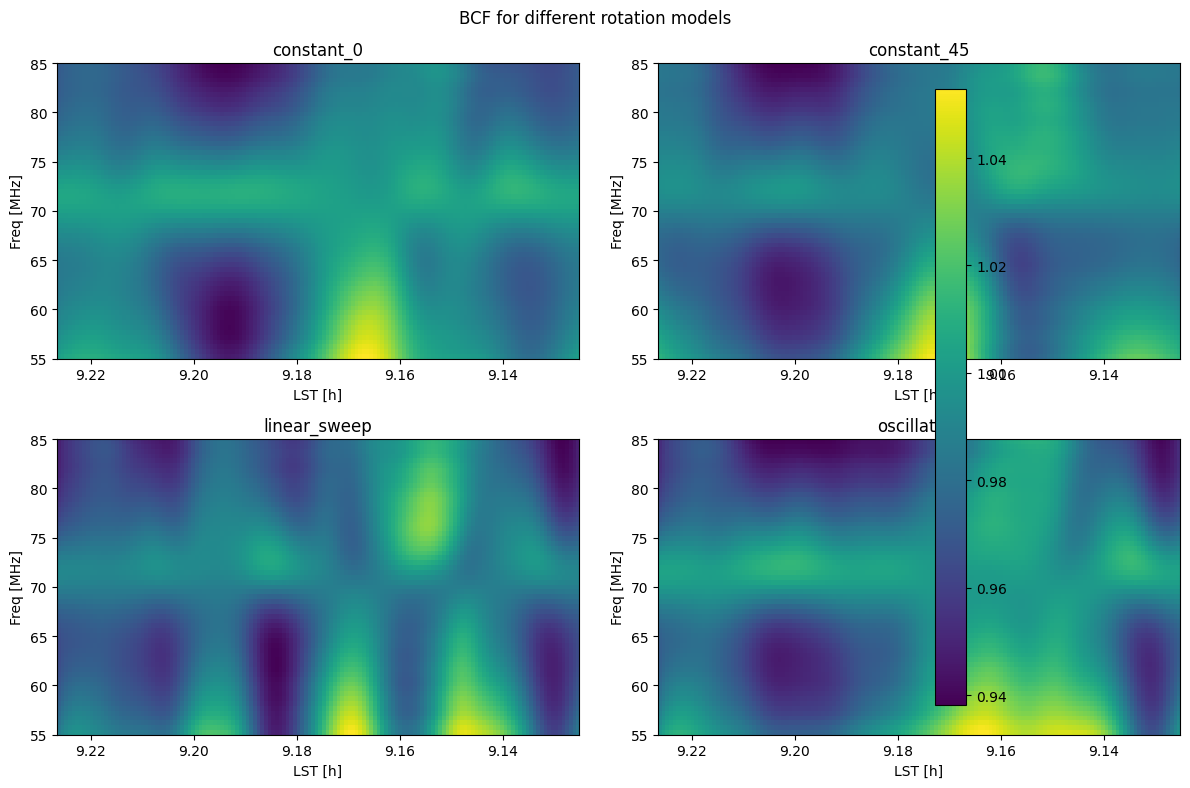

/var/folders/y0/4z9tprvs2qb6qwgklyjc_tbw0000gp/T/ipykernel_45492/753437276.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


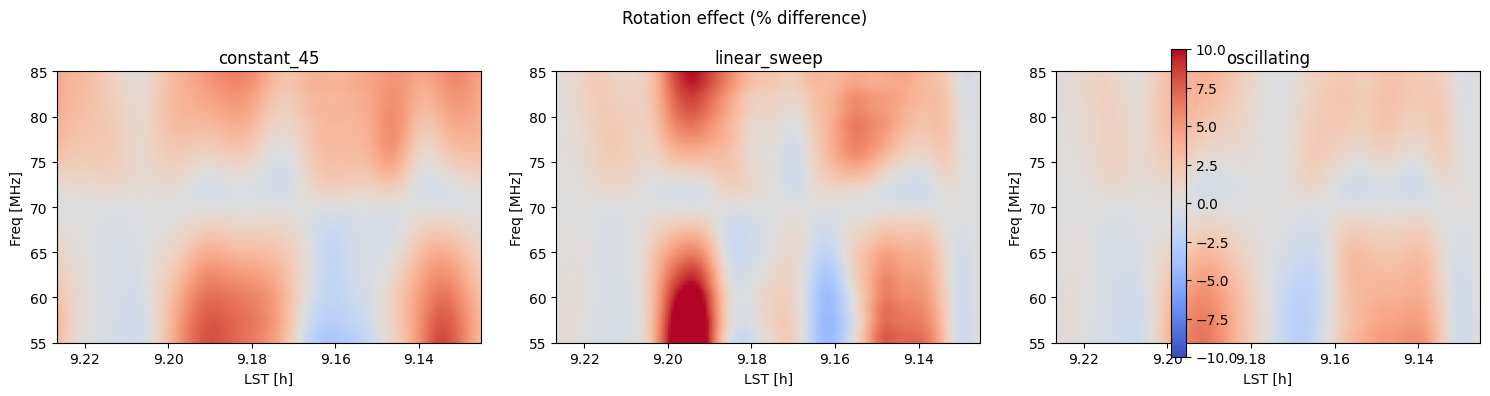

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.io import fits
import glob, re

from limTOD import TODSim, generate_TOD_sky, generate_LSTs_deg
from limTOD import GDSM_sky_model

# ============================================================
# CONFIG
# ============================================================

BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100

START_TIME = "2026-04-01 20:41:56.397"

SIDEREAL_DAY_SEC = 23.934 * 3600
DT = 600
time_list = np.arange(0, SIDEREAL_DAY_SEC, DT)

BEAM_NSIDE = 512
SKY_NSIDE = 64
NSIDE_HIRES = 128

REF_FREQ = 70

# ============================================================
# LOAD BEAMS
# ============================================================

beam_files = sorted(glob.glob(BEAM_GLOB))

beam_dict = {}

for f in beam_files:
    freq = float(re.search(r"(\d+\.\d+)", f).group(1))

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data.field(0)).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0
    beam /= np.sum(beam)

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))
ref_freq = freq_list[np.argmin(np.abs(freq_list - REF_FREQ))]

def beam_func(*, freq, nside):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near]

    if hp.npix2nside(len(beam)) != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    beam /= np.sum(beam)
    return beam

# ============================================================
# SKY + LST
# ============================================================

LST_deg = generate_LSTs_deg(
    ANT_LAT, ANT_LON, ANT_H,
    time_list,
    start_time_utc=START_TIME
)

az_list = np.zeros(len(time_list))
el_list = np.full(len(time_list), 90.0)

# ============================================================
# ROTATION MODELS
# ============================================================

rotation_models = {
    "constant_0": lambda t: np.zeros_like(t),
    "constant_45": lambda t: np.full_like(t, 45),
    "linear_sweep": lambda t: (t / t.max()) * 360,
    "oscillating": lambda t: 45 * np.sin(2*np.pi * t / t.max())
}

# ============================================================
# BCF CALCULATION FUNCTION
# ============================================================

def compute_bcf(sr_list):

    ref_sky = GDSM_sky_model(freq=ref_freq, nside=SKY_NSIDE)

    ref_beam = beam_func(freq=ref_freq, nside=BEAM_NSIDE)

    ref_conv = generate_TOD_sky(
        ref_beam, ref_sky,
        LST_deg, ANT_LAT,
        az_list, el_list, sr_list,
        nside_hires=NSIDE_HIRES,
        normalize_beam=True
    )

    BCF = np.zeros((len(time_list), len(freq_list)))

    for i, nu in enumerate(freq_list):

        beam_nu = beam_func(freq=nu, nside=BEAM_NSIDE)

        conv = generate_TOD_sky(
            beam_nu, ref_sky,
            LST_deg, ANT_LAT,
            az_list, el_list, sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True
        )

        BCF[:, i] = conv / ref_conv

    return BCF

# ============================================================
# RUN ALL MODELS
# ============================================================

BCF_results = {}

for name, func in rotation_models.items():
    print("Running:", name)

    sr_list = func(time_list)
    BCF_results[name] = compute_bcf(sr_list)

# ============================================================
# PLOT 1 — BCF MAPS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, (name, BCF) in zip(axes, BCF_results.items()):

    im = ax.imshow(
        BCF.T,
        aspect="auto",
        origin="lower",
        extent=[
            LST_deg[0]/15,
            LST_deg[-1]/15,
            freq_list[0],
            freq_list[-1]
        ]
    )

    ax.set_title(name)
    ax.set_xlabel("LST [h]")
    ax.set_ylabel("Freq [MHz]")

plt.colorbar(im, ax=axes)
plt.suptitle("BCF for different rotation models")
plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2 — % DIFFERENCE vs CONSTANT 0
# ============================================================

ref = BCF_results["constant_0"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name in zip(axes, ["constant_45", "linear_sweep", "oscillating"]):

    diff = (BCF_results[name] / ref - 1) * 100

    im = ax.imshow(
        diff.T,
        aspect="auto",
        origin="lower",
        extent=[
            LST_deg[0]/15,
            LST_deg[-1]/15,
            freq_list[0],
            freq_list[-1]
        ],
        cmap="coolwarm",
        vmin=-10, vmax=10
    )

    ax.set_title(name)
    ax.set_xlabel("LST [h]")
    ax.set_ylabel("Freq [MHz]")

plt.colorbar(im, ax=axes)
plt.suptitle("Rotation effect (% difference)")
plt.tight_layout()
plt.show()

### A better trial

Running: fixed


100%|██████████| 72/72 [00:02<00:00, 24.11it/s]


Running: stepped


100%|██████████| 72/72 [00:03<00:00, 23.70it/s]


Running: continuous


100%|██████████| 72/72 [00:03<00:00, 23.36it/s]


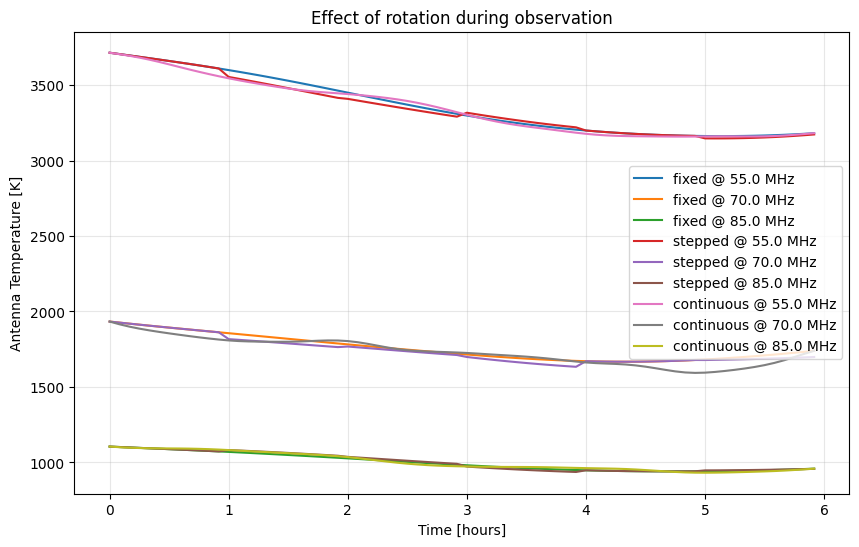

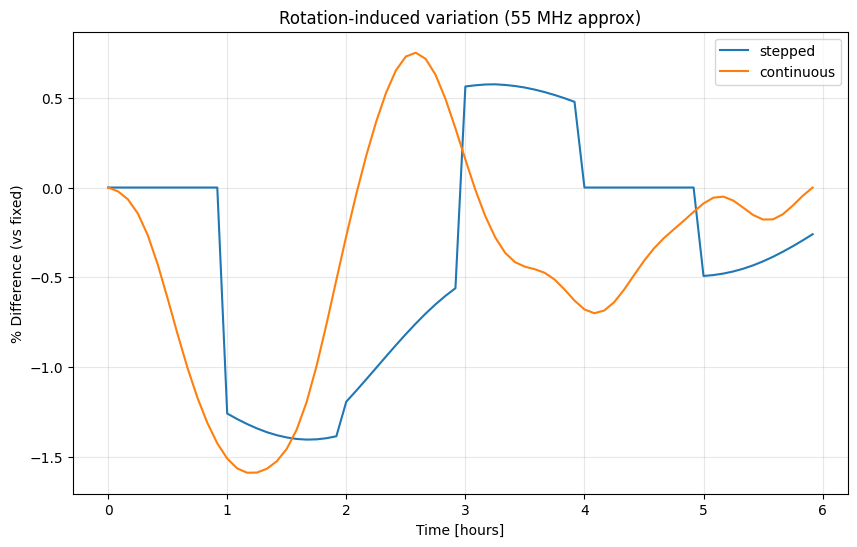

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.io import fits
import glob, re

from limTOD import generate_TOD_sky, generate_LSTs_deg
from limTOD import GDSM_sky_model

# ============================================================
# CONFIG
# ============================================================

BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100

START_TIME = "2026-04-01 20:41:56.397"

# 6-hour observation
DT = 300   # 5 min sampling
N_TIME = int((6 * 3600) / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600

BEAM_NSIDE = 512
SKY_NSIDE = 64
NSIDE_HIRES = 128

# ============================================================
# LOAD BEAMS
# ============================================================

beam_files = sorted(glob.glob(BEAM_GLOB))

beam_dict = {}

for f in beam_files:
    freq = float(re.search(r"(\d+\.\d+)", f).group(1))

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data.field(0)).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0
    beam /= np.sum(beam)

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))

def beam_func(freq, nside):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near]

    if hp.npix2nside(len(beam)) != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    return beam / np.sum(beam)

# ============================================================
# SKY + LST
# ============================================================

LST_deg = generate_LSTs_deg(
    ANT_LAT, ANT_LON, ANT_H,
    time_list,
    start_time_utc=START_TIME
)

az_list = np.zeros(N_TIME)
el_list = np.full(N_TIME, 90.0)

# ============================================================
# ROTATION MODELS
# ============================================================

# fixed
sr_fixed = np.zeros(N_TIME)

# stepped (change every hour)
sr_step = np.zeros(N_TIME)
step_deg = [0, 45, 90, 135]
for i in range(N_TIME):
    sr_step[i] = step_deg[(i // (3600 // DT)) % len(step_deg)]

# 3️⃣ continuous rotation
sr_cont = (time_list / time_list[-1]) * 360

rotation_cases = {
    "fixed": sr_fixed,
    "stepped": sr_step,
    "continuous": sr_cont
}

# ============================================================
# COMPUTE ANTENNA TEMPERATURE
# ============================================================

def compute_T(sr_list):

    T = np.zeros((len(freq_list), N_TIME))

    for i, nu in enumerate(freq_list):

        beam = beam_func(nu, BEAM_NSIDE)
        sky = GDSM_sky_model(freq=nu, nside=SKY_NSIDE)

        T[i] = generate_TOD_sky(
            beam, sky,
            LST_deg, ANT_LAT,
            az_list, el_list, sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True
        )

    return T

results = {}

for name, sr in rotation_cases.items():
    print("Running:", name)
    results[name] = compute_T(sr)

# ============================================================
# PLOT 1 — TIME SERIES (few frequencies)
# ============================================================

plt.figure(figsize=(10,6))

freq_indices = [0, len(freq_list)//2, -1]  # low, mid, high freq

for name, T in results.items():
    for idx in freq_indices:
        plt.plot(
            time_hours,
            T[idx],
            label=f"{name} @ {freq_list[idx]:.1f} MHz"
        )

plt.xlabel("Time [hours]")
plt.ylabel("Antenna Temperature [K]")
plt.title("Effect of rotation during observation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 2 — DIFFERENCE vs FIXED
# ============================================================

plt.figure(figsize=(10,6))

T_ref = results["fixed"]

for name in ["stepped", "continuous"]:
    T = results[name]

    diff = (T - T_ref) / T_ref * 100

    plt.plot(
        time_hours,
        diff[0],   # lowest freq (most sensitive)
        label=f"{name}"
    )

plt.xlabel("Time [hours]")
plt.ylabel("% Difference (vs fixed)")
plt.title("Rotation-induced variation (55 MHz approx)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

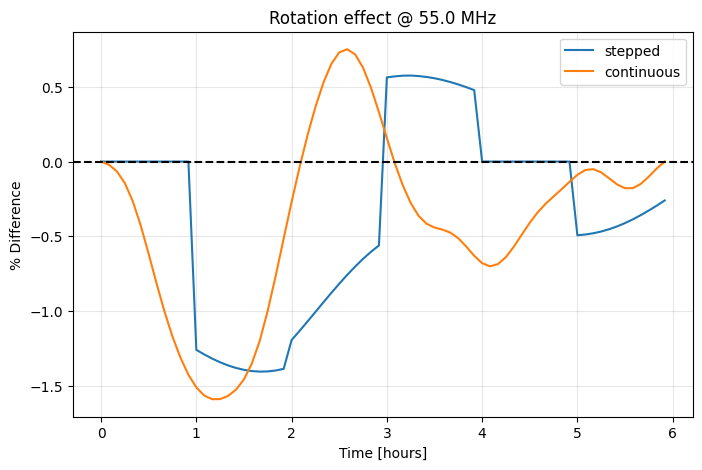

In [29]:
plt.figure(figsize=(8,5))

freq_idx = 0  # pick 55 MHz

for name in ["stepped", "continuous"]:
    diff = (results[name][freq_idx] - results["fixed"][freq_idx]) / results["fixed"][freq_idx] * 100

    plt.plot(time_hours, diff, label=name)

plt.axhline(0, color='k', linestyle='--')

plt.xlabel("Time [hours]")
plt.ylabel("% Difference")
plt.title(f"Rotation effect @ {freq_list[freq_idx]:.1f} MHz")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

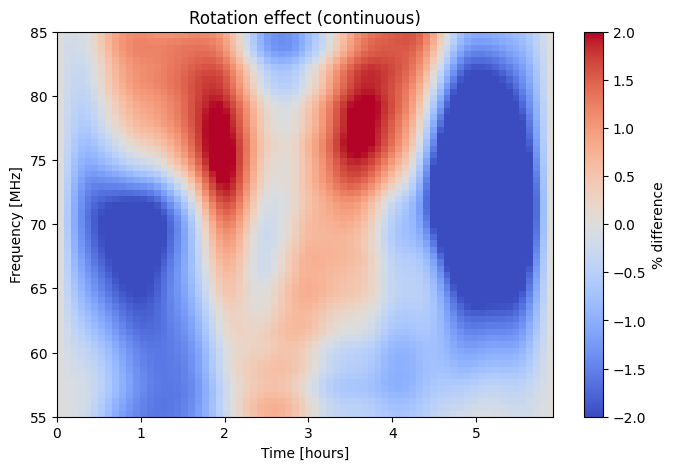

In [30]:
diff = (results["continuous"] - results["fixed"]) / results["fixed"] * 100

plt.figure(figsize=(8,5))

plt.imshow(
    diff,
    aspect="auto",
    origin="lower",
    extent=[
        time_hours[0],
        time_hours[-1],
        freq_list[0],
        freq_list[-1]
    ],
    cmap="coolwarm",
    vmin=-2, vmax=2
)

plt.colorbar(label="% difference")

plt.xlabel("Time [hours]")
plt.ylabel("Frequency [MHz]")
plt.title("Rotation effect (continuous)")

plt.show()

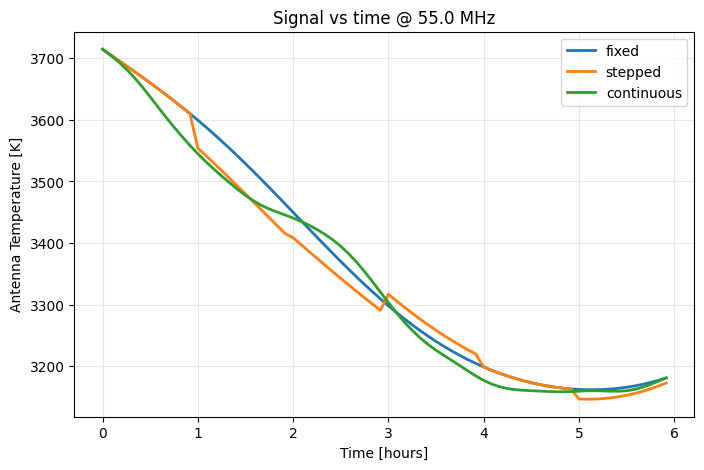

In [31]:
plt.figure(figsize=(8,5))

freq_idx = 0   # 55 MHz (most sensitive)

for name in ["fixed", "stepped", "continuous"]:
    plt.plot(
        time_hours,
        results[name][freq_idx],
        label=name,
        linewidth=2
    )

plt.xlabel("Time [hours]")
plt.ylabel("Antenna Temperature [K]")
plt.title(f"Signal vs time @ {freq_list[freq_idx]:.1f} MHz")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

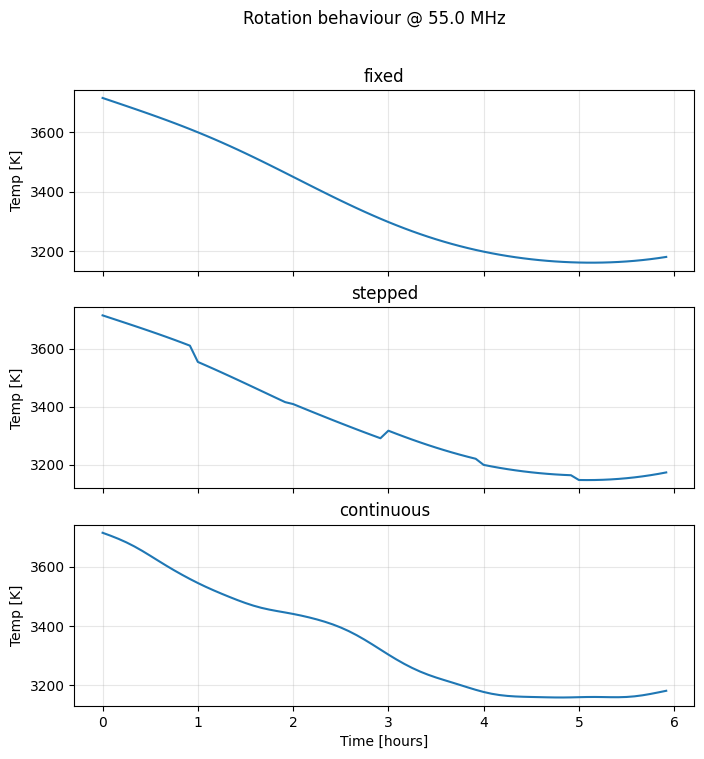

In [32]:
fig, axs = plt.subplots(3, 1, figsize=(8,8), sharex=True)

freq_idx = 0

for ax, name in zip(axs, ["fixed", "stepped", "continuous"]):
    ax.plot(time_hours, results[name][freq_idx])
    ax.set_title(name)
    ax.set_ylabel("Temp [K]")
    ax.grid(alpha=0.3)

axs[-1].set_xlabel("Time [hours]")

plt.suptitle(f"Rotation behaviour @ {freq_list[freq_idx]:.1f} MHz")
plt.show()

### With BCF

Running: fixed


100%|██████████| 72/72 [00:03<00:00, 23.21it/s]


Using reference frequency: 70.00 MHz


100%|██████████| 72/72 [00:03<00:00, 21.87it/s]


Running: stepped


...

100%|██████████| 72/72 [00:03<00:00, 21.80it/s]


Running: continuous


100%|██████████| 72/72 [00:04<00:00, 15.38it/s]


Using reference frequency: 70.00 MHz


100%|██████████| 72/72 [00:04<00:00, 15.83it/s]


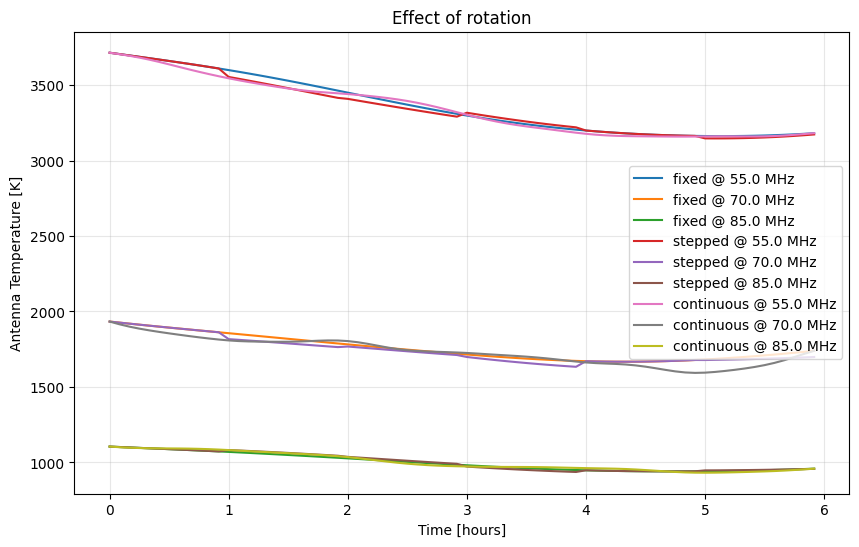

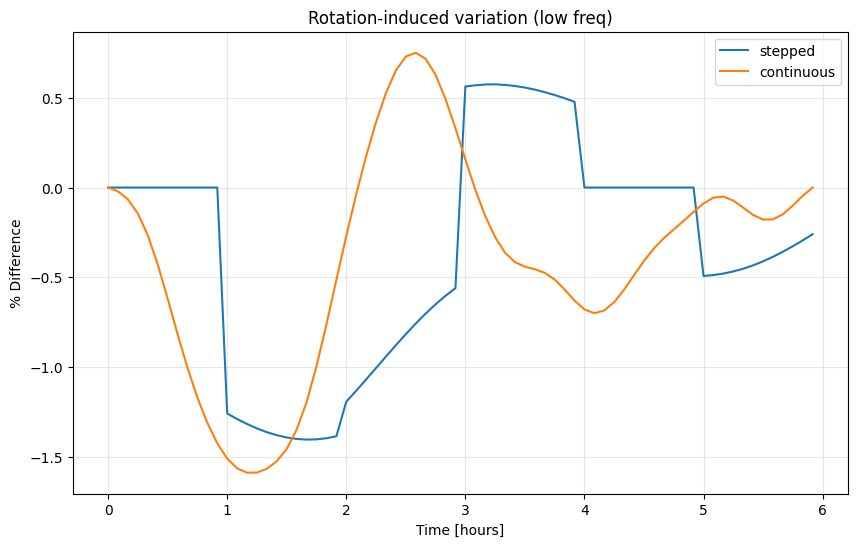

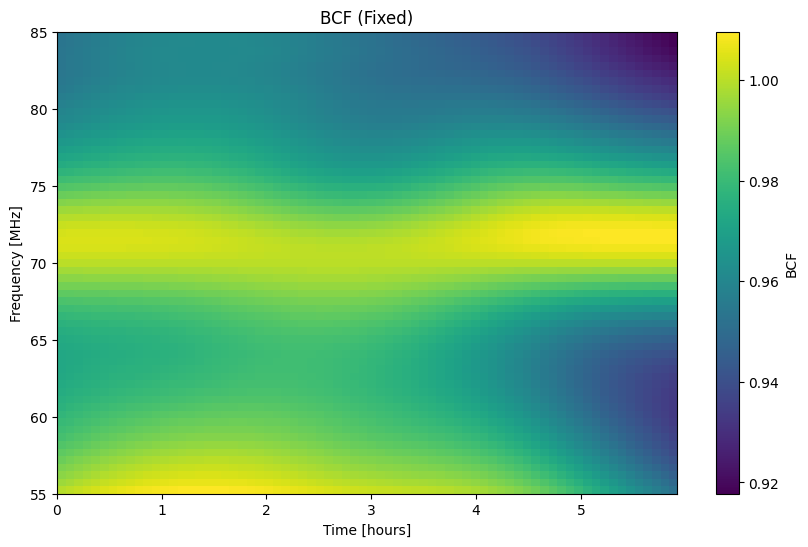

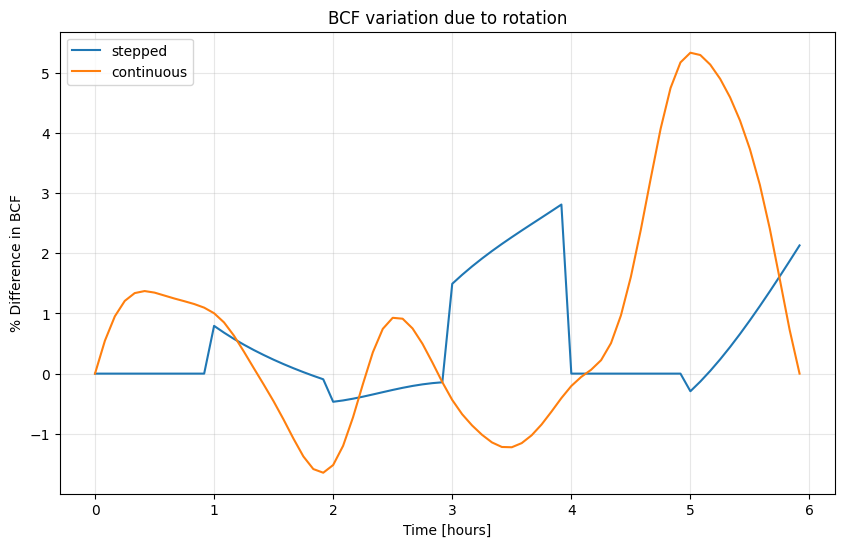

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import healpy as hp
from astropy.io import fits
import glob, re

from limTOD import generate_TOD_sky, generate_LSTs_deg
from limTOD import GDSM_sky_model

# ============================================================
# CONFIG
# ============================================================

BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100

START_TIME = "2026-04-01 20:41:56.397"

# 6-hour observation
DT = 300   # 5 min sampling
N_TIME = int((6 * 3600) / DT)

time_list = np.arange(N_TIME) * DT
time_hours = time_list / 3600

BEAM_NSIDE = 512
SKY_NSIDE = 64
NSIDE_HIRES = 128

# ============================================================
# LOAD BEAMS
# ============================================================

beam_files = sorted(glob.glob(BEAM_GLOB))

beam_dict = {}

for f in beam_files:
    freq = float(re.search(r"(\d+\.\d+)", f).group(1))

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data.field(0)).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0
    beam /= np.sum(beam)

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))

def beam_func(freq, nside):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near]

    if hp.npix2nside(len(beam)) != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    return beam / np.sum(beam)

# ============================================================
# SKY + LST
# ============================================================

LST_deg = generate_LSTs_deg(
    ANT_LAT, ANT_LON, ANT_H,
    time_list,
    start_time_utc=START_TIME
)

az_list = np.zeros(N_TIME)
el_list = np.full(N_TIME, 90.0)

# ============================================================
# ROTATION MODELS
# ============================================================

# fixed
sr_fixed = np.zeros(N_TIME)

# stepped (change every hour)
sr_step = np.zeros(N_TIME)
step_deg = [0, 45, 90, 135]
for i in range(N_TIME):
    sr_step[i] = step_deg[(i // (3600 // DT)) % len(step_deg)]

# continuous
sr_cont = (time_list / time_list[-1]) * 360

rotation_cases = {
    "fixed": sr_fixed,
    "stepped": sr_step,
    "continuous": sr_cont
}

# ============================================================
# COMPUTE ANTENNA TEMPERATURE
# ============================================================

def compute_T(sr_list):

    T = np.zeros((len(freq_list), N_TIME))

    for i, nu in enumerate(freq_list):

        beam = beam_func(nu, BEAM_NSIDE)
        sky = GDSM_sky_model(freq=nu, nside=SKY_NSIDE)

        T[i] = generate_TOD_sky(
            beam, sky,
            LST_deg, ANT_LAT,
            az_list, el_list, sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True
        )

    return T

# ============================================================
# COMPUTE BCF (FROM PAPER EQ. 4)
# ============================================================

def compute_BCF(sr_list, nu_ref=70.0):

    # reference frequency
    nu_ref_idx = np.argmin(np.abs(freq_list - nu_ref))
    nu_ref_actual = freq_list[nu_ref_idx]
    print(f"Using reference frequency: {nu_ref_actual:.2f} MHz")

    # sky at reference frequency
    sky_ref = GDSM_sky_model(freq=nu_ref_actual, nside=SKY_NSIDE)

    # reference beam
    beam_ref = beam_func(nu_ref_actual, BEAM_NSIDE)

    # denominator (time dependent)
    T_ref = generate_TOD_sky(
        beam_ref, sky_ref,
        LST_deg, ANT_LAT,
        az_list, el_list, sr_list,
        nside_hires=NSIDE_HIRES,
        normalize_beam=True
    )

    BCF = np.zeros((len(freq_list), N_TIME))

    for i, nu in enumerate(freq_list):

        beam = beam_func(nu, BEAM_NSIDE)

        T_num = generate_TOD_sky(
            beam, sky_ref,
            LST_deg, ANT_LAT,
            az_list, el_list, sr_list,
            nside_hires=NSIDE_HIRES,
            normalize_beam=True
        )

        BCF[i] = T_num / T_ref

    return BCF

# ============================================================
# RUN SIMULATIONS
# ============================================================

results = {}
bcf_results = {}

for name, sr in rotation_cases.items():
    print("Running:", name)

    results[name] = compute_T(sr)
    bcf_results[name] = compute_BCF(sr)

# ============================================================
# PLOT 1 — TIME SERIES
# ============================================================

plt.figure(figsize=(10,6))

freq_indices = [0, len(freq_list)//2, -1]

for name, T in results.items():
    for idx in freq_indices:
        plt.plot(
            time_hours,
            T[idx],
            label=f"{name} @ {freq_list[idx]:.1f} MHz"
        )

plt.xlabel("Time [hours]")
plt.ylabel("Antenna Temperature [K]")
plt.title("Effect of rotation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 2 — ANTENNA TEMP DIFFERENCE
# ============================================================

plt.figure(figsize=(10,6))

T_ref = results["fixed"]

for name in ["stepped", "continuous"]:
    diff = (results[name] - T_ref) / T_ref * 100
    plt.plot(time_hours, diff[0], label=name)

plt.xlabel("Time [hours]")
plt.ylabel("% Difference")
plt.title("Rotation-induced variation (low freq)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# PLOT 3 — BCF WATERFALL
# ============================================================

plt.figure(figsize=(10,6))

plt.imshow(
    bcf_results["fixed"],
    aspect="auto",
    origin="lower",
    extent=[time_hours[0], time_hours[-1],
            freq_list[0], freq_list[-1]]
)

plt.colorbar(label="BCF")
plt.xlabel("Time [hours]")
plt.ylabel("Frequency [MHz]")
plt.title("BCF (Fixed)")
plt.show()

# ============================================================
# PLOT 4 — BCF DIFFERENCE
# ============================================================

plt.figure(figsize=(10,6))

bcf_ref = bcf_results["fixed"]

for name in ["stepped", "continuous"]:
    diff = (bcf_results[name] - bcf_ref) / bcf_ref * 100
    plt.plot(time_hours, diff[0], label=name)

plt.xlabel("Time [hours]")
plt.ylabel("% Difference in BCF")
plt.title("BCF variation due to rotation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [2]:
Tcorr_results = {}

for name in results:
    Tcorr_results[name] = results[name] / bcf_results[name]

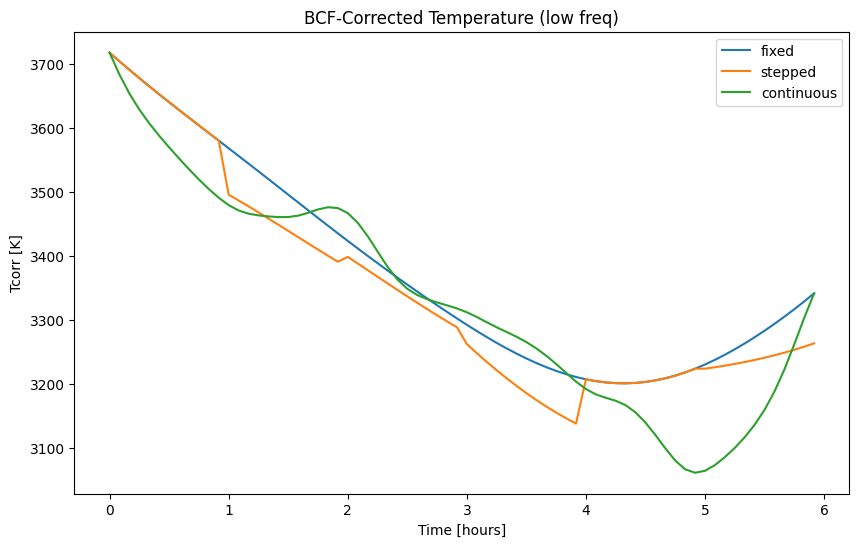

In [3]:
plt.figure(figsize=(10,6))

for name, Tcorr in Tcorr_results.items():
    plt.plot(time_hours, Tcorr[0], label=name)

plt.title("BCF-Corrected Temperature (low freq)")
plt.xlabel("Time [hours]")
plt.ylabel("Tcorr [K]")
plt.legend()
plt.show()

In [4]:
# raw
def rms_diff(T1, T2):
    return np.sqrt(np.mean((T1 - T2)**2))

rms_raw = rms_diff(results["continuous"][0], results["fixed"][0])

# corrected
rms_corr = rms_diff(Tcorr_results["continuous"][0], Tcorr_results["fixed"][0])

print("RMS raw:", rms_raw)
print("RMS corrected:", rms_corr)

RMS raw: 25.34188160917604
RMS corrected: 72.14658326929225


In [5]:
def peak_to_peak(T):
    return np.max(T) - np.min(T)

print("Raw p2p:", peak_to_peak(results["continuous"][0]))
print("Corrected p2p:", peak_to_peak(Tcorr_results["continuous"][0]))

Raw p2p: 555.8091709830378
Corrected p2p: 656.5022067804598


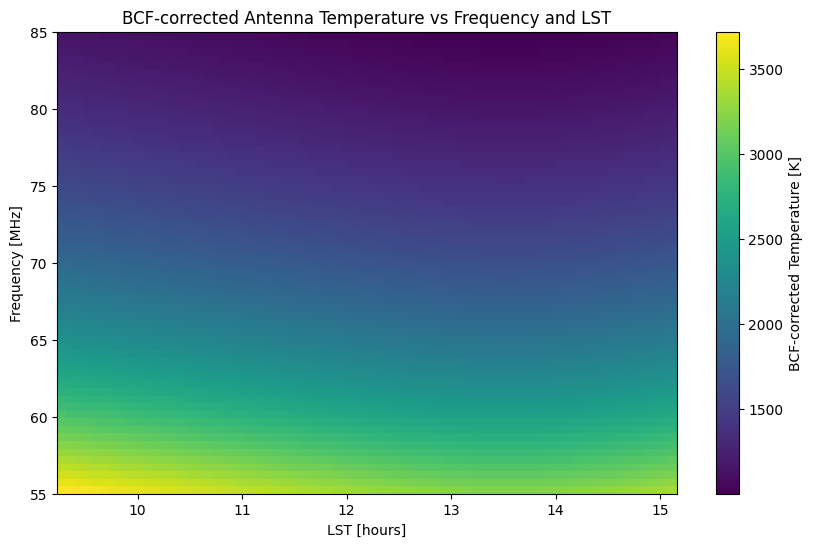

In [7]:
LST_hours = LST_deg / 15.0

plt.figure(figsize=(10,6))

Tcorr = Tcorr_results["fixed"]  # choose rotation case

plt.imshow(
    Tcorr,
    aspect="auto",
    origin="lower",
    extent=[
        LST_hours[0], LST_hours[-1],
        freq_list[0], freq_list[-1]
    ]
)

plt.colorbar(label="BCF-corrected Temperature [K]")

plt.xlabel("LST [hours]")
plt.ylabel("Frequency [MHz]")
plt.title("BCF-corrected Antenna Temperature vs Frequency and LST")

plt.show()

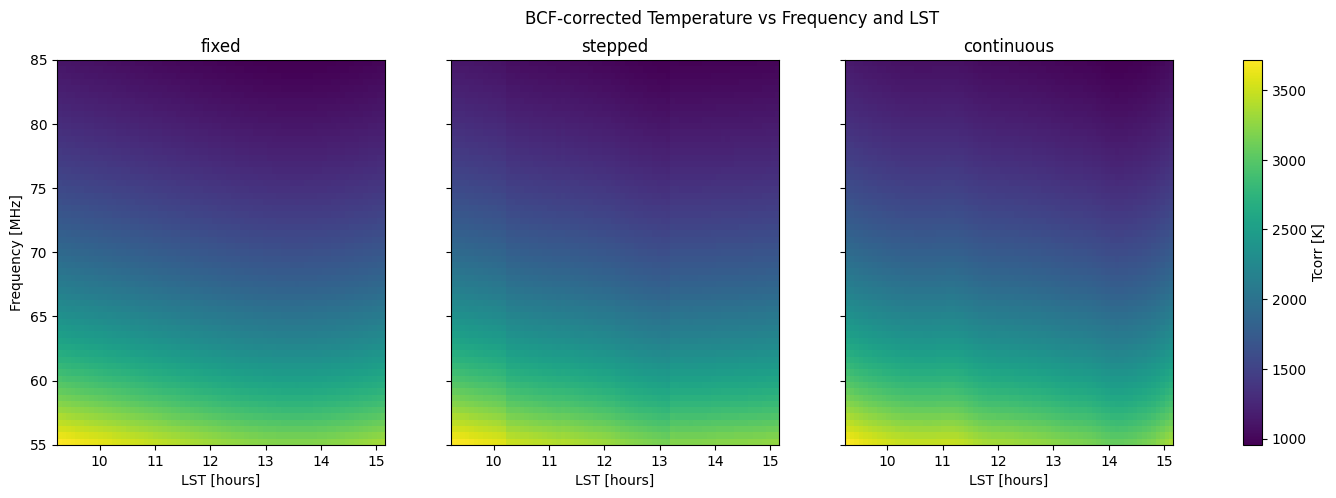

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for ax, name in zip(axes, ["fixed", "stepped", "continuous"]):

    Tcorr = Tcorr_results[name]

    im = ax.imshow(
        Tcorr,
        aspect="auto",
        origin="lower",
        extent=[
            LST_hours[0], LST_hours[-1],
            freq_list[0], freq_list[-1]
        ]
    )

    ax.set_title(name)
    ax.set_xlabel("LST [hours]")

axes[0].set_ylabel("Frequency [MHz]")

fig.colorbar(im, ax=axes, label="Tcorr [K]")
plt.suptitle("BCF-corrected Temperature vs Frequency and LST")

plt.show()

In [9]:
def fit_and_subtract_poly(freq, spectrum, order=3):
    """
    Fit polynomial and return residual
    """
    coeffs = np.polyfit(freq, spectrum, order)
    model = np.polyval(coeffs, freq)
    residual = spectrum - model
    return residual, model

In [10]:
def compute_residuals(Tcorr, freq_list, order=3):

    n_freq, n_time = Tcorr.shape
    residuals = np.zeros_like(Tcorr)

    for t in range(n_time):
        spec = Tcorr[:, t]

        res, _ = fit_and_subtract_poly(freq_list, spec, order)
        residuals[:, t] = res

    return residuals

In [11]:
residual_results = {}

for name in Tcorr_results:
    residual_results[name] = compute_residuals(
        Tcorr_results[name],
        freq_list,
        order=3   # try 3–5
    )

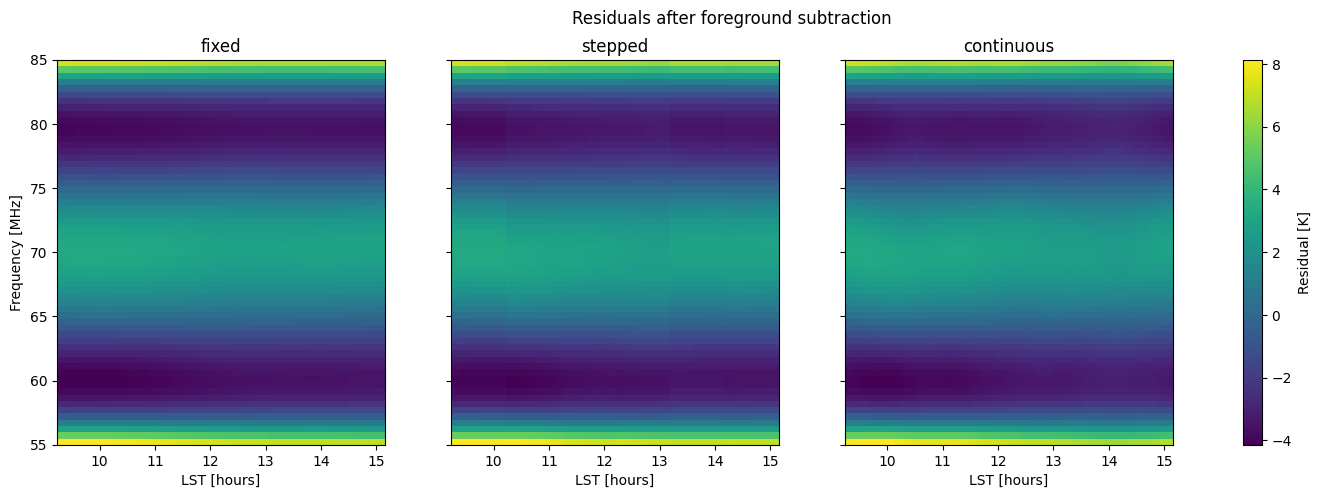

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18,5), sharey=True)

for ax, name in zip(axes, ["fixed", "stepped", "continuous"]):

    im = ax.imshow(
        residual_results[name],
        aspect="auto",
        origin="lower",
        extent=[
            LST_hours[0], LST_hours[-1],
            freq_list[0], freq_list[-1]
        ]
    )

    ax.set_title(name)
    ax.set_xlabel("LST [hours]")

axes[0].set_ylabel("Frequency [MHz]")
fig.colorbar(im, ax=axes, label="Residual [K]")

plt.suptitle("Residuals after foreground subtraction")
plt.show()

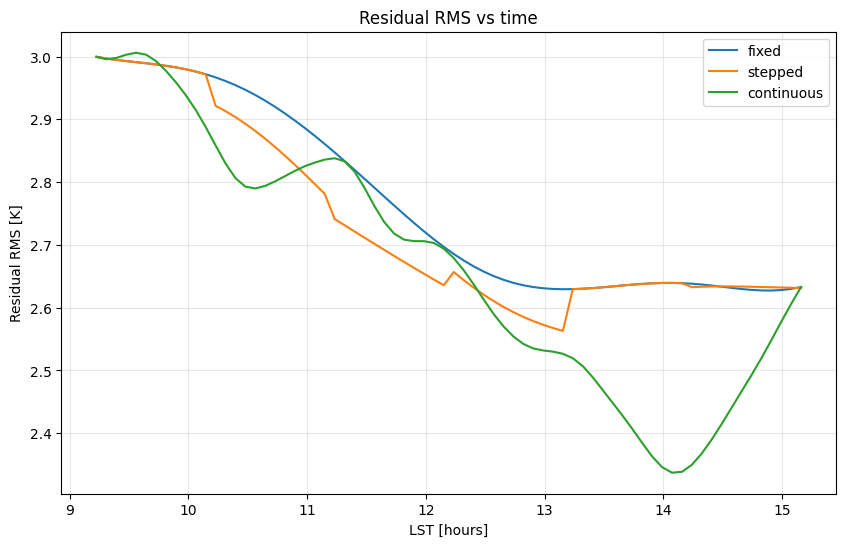

In [14]:
def compute_rms(residuals):
    return np.sqrt(np.mean(residuals**2, axis=0))  # over freq

plt.figure(figsize=(10,6))

for name in residual_results:
    rms = compute_rms(residual_results[name])
    plt.plot(LST_hours, rms, label=name)

plt.xlabel("LST [hours]")
plt.ylabel("Residual RMS [K]")
plt.title("Residual RMS vs time")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

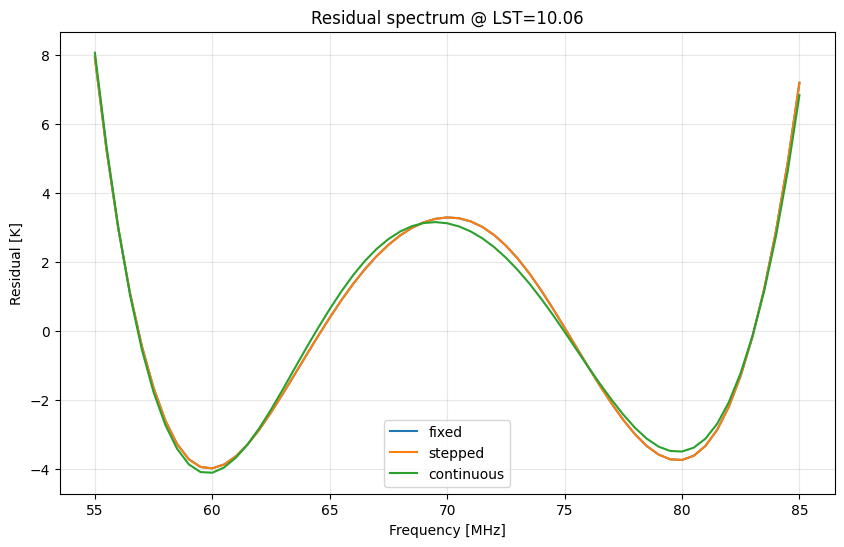

In [15]:
t_idx = 10  # pick a time

plt.figure(figsize=(10,6))

for name in residual_results:
    plt.plot(
        freq_list,
        residual_results[name][:, t_idx],
        label=name
    )

plt.xlabel("Frequency [MHz]")
plt.ylabel("Residual [K]")
plt.title(f"Residual spectrum @ LST={LST_hours[t_idx]:.2f}")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [17]:
Tcorr_results = {}

for name in results:
    Tcorr_results[name] = results[name] / bcf_results[name]

Using horn beam at target frequency 55.00 MHz
Using horn beam at reference frequency 70.00 MHz


100%|██████████| 4320/4320 [03:59<00:00, 18.06it/s]


Raw TOD shape: (4320,)


100%|██████████| 4320/4320 [03:55<00:00, 18.38it/s]


BCF shape: (4320,)
BCF min = 0.916043, max = 1.082457
BCF-corrected TOD shape: (4320,)

Step 1: Generating the stacked abs(beam) map ... 



100%|██████████| 4320/4320 [04:02<00:00, 17.78it/s]



Step 2: Selecting pixels above threshold sensitivity ... 

Number of data points: 4320
Number of selected pixels: 1568


100%|██████████| 4320/4320 [04:07<00:00, 17.46it/s]


Recovered sky parameter shape: (1568,)
Recovered uncertainty shape: (1568,)
Number of selected pixels: 1568


ValueError: x and y must have same first dimension, but have shapes (72,) and (4320,)

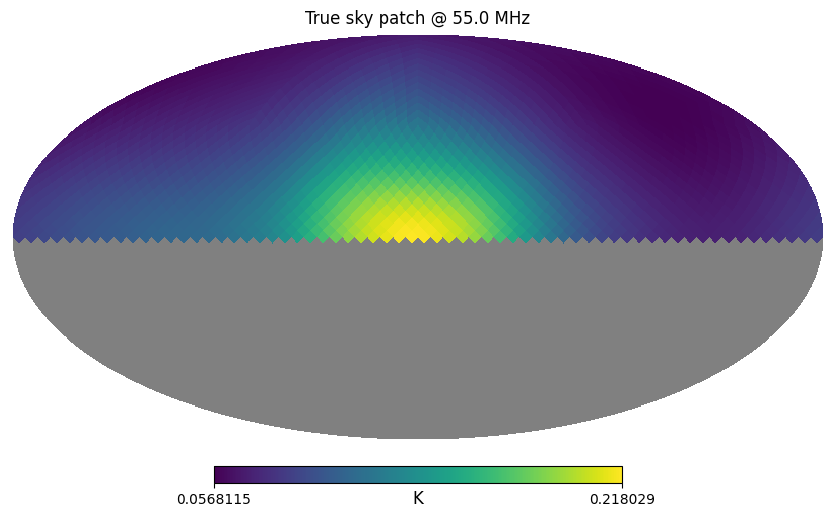

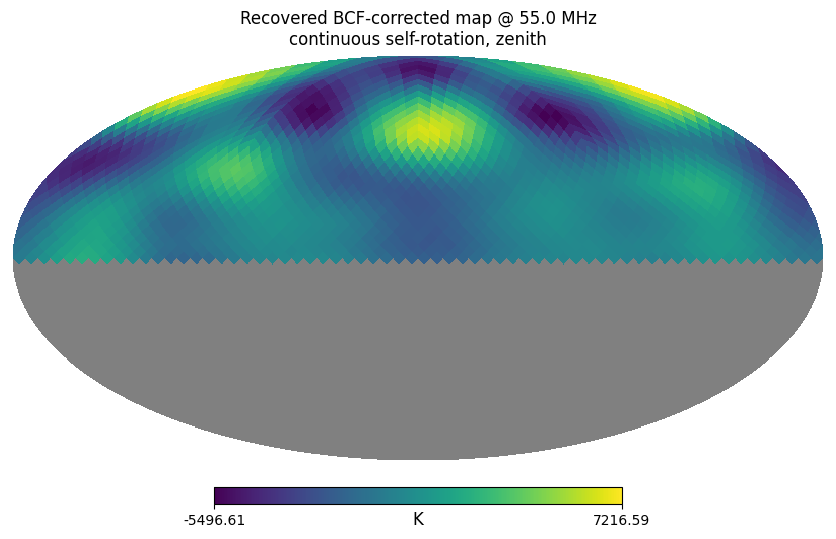

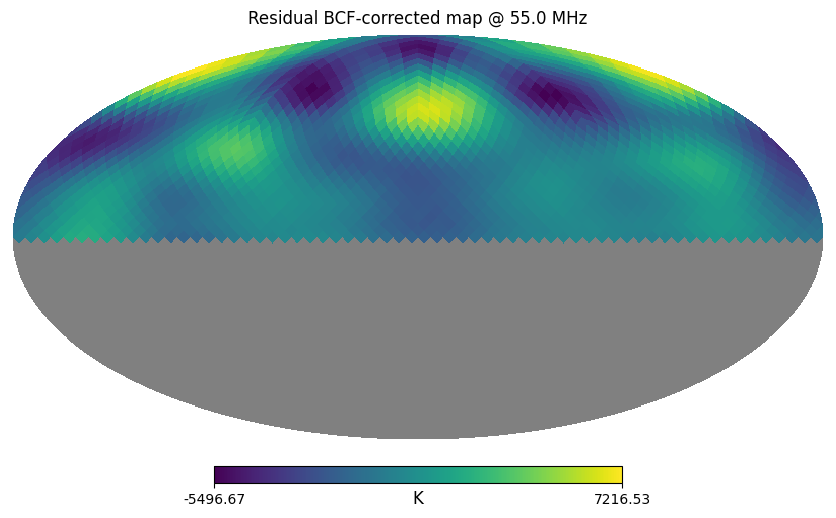

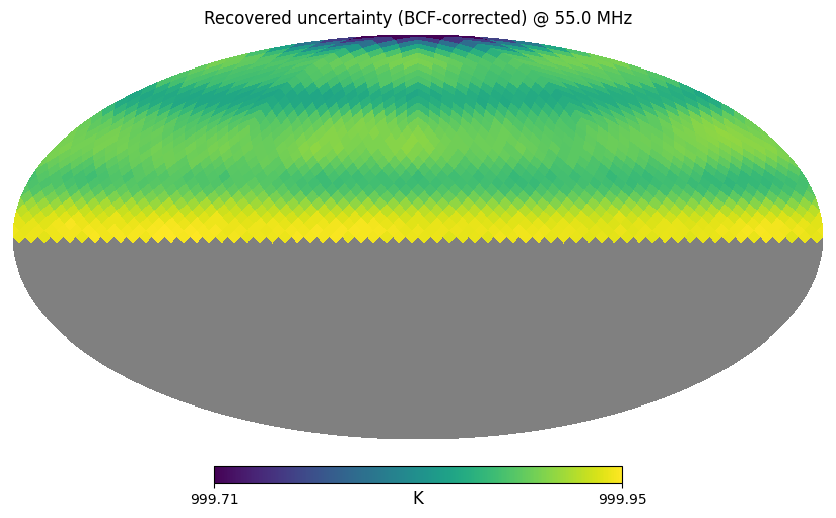

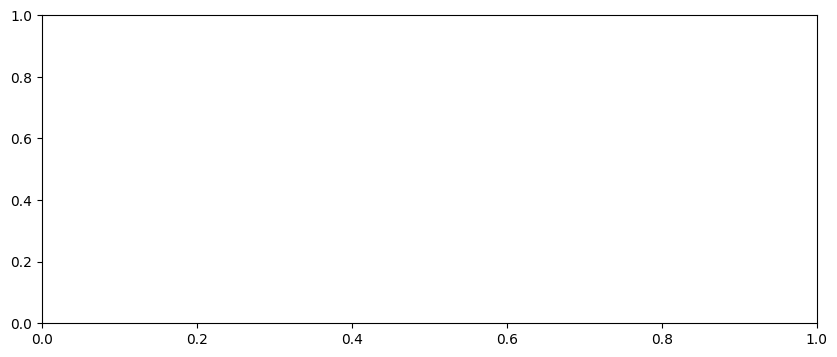

In [ ]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
from astropy.io import fits
import glob
import re

from limTOD import generate_LSTs_deg, generate_TOD_sky, GDSM_sky_model, HPW_mapmaking

# ============================================================
# CONFIG
# ============================================================

BEAM_GLOB = "../data/HornWet/HornWet*.fits"

ANT_LAT = 53.2421
ANT_LON = -2.3067
ANT_H   = 100.0

START_TIME = "2026-04-01 20:41:56.397"

# DT = 60.0                       # 1 min cadence
# N_HOURS = 24
# N_TIME = int((N_HOURS * 3600) / DT)

# time_list = np.arange(N_TIME) * DT
# time_hours = time_list / 3600.0

DT = 20.0
N_HOURS = 24
N_TIME = int((N_HOURS * 3600) / DT)

time_list = np.arange(N_TIME) * DT

# one full rotation every 60 s
rotation_period_sec = 3600.0
selfrot_deg_list = (time_list / rotation_period_sec * 360.0) % 360.0

BEAM_NSIDE = 128
SKY_NSIDE = 32
MAP_NSIDE = 16                 # target map nside for reconstruction

TARGET_FREQ = 55.0              # target horn-beam channel
REF_FREQ = 70.0                 # BCF reference frequency

# continuous self rotation: 0 -> 360 over whole observation
# selfrot_deg_list = (time_list / time_list[-1]) * 360.0

# zenith pointing
azimuth_deg_list = np.zeros(N_TIME)
elevation_deg_list = np.full(N_TIME, 90.0)

# ============================================================
# LOAD HORN BEAMS
# ============================================================

beam_files = sorted(glob.glob(BEAM_GLOB))
if len(beam_files) == 0:
    raise FileNotFoundError(f"No beam FITS found matching {BEAM_GLOB}")

beam_dict = {}

for f in beam_files:
    m = re.search(r"(\d+\.\d+)", f)
    if m is None:
        continue

    freq = float(m.group(1))

    with fits.open(f) as hdul:
        beam = np.array(hdul[1].data.field(0)).reshape(-1)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0.0
    beam /= np.sum(beam)

    beam_dict[freq] = beam

freq_list = np.array(sorted(beam_dict.keys()))
if len(freq_list) == 0:
    raise RuntimeError("No usable horn beams were loaded.")

def get_horn_beam_for_freq(freq, nside=BEAM_NSIDE):
    f_near = freq_list[np.argmin(np.abs(freq_list - freq))]
    beam = beam_dict[f_near].copy()

    native_nside = hp.npix2nside(len(beam))
    if native_nside != nside:
        beam = hp.ud_grade(beam, nside_out=nside, power=-2)

    beam = np.nan_to_num(beam)
    beam[beam < 0] = 0.0

    s = np.sum(beam)
    if s <= 0:
        raise ValueError(f"Beam at {f_near} MHz has zero total weight.")
    beam /= s

    return f_near, beam

beam_freq_used, beam_map = get_horn_beam_for_freq(TARGET_FREQ, nside=BEAM_NSIDE)
ref_freq_used, beam_ref_map = get_horn_beam_for_freq(REF_FREQ, nside=BEAM_NSIDE)

print(f"Using horn beam at target frequency {beam_freq_used:.2f} MHz")
print(f"Using horn beam at reference frequency {ref_freq_used:.2f} MHz")

# ============================================================
# GENERATE SKY + LST
# ============================================================

LST_deg_list = generate_LSTs_deg(
    ANT_LAT,
    ANT_LON,
    ANT_H,
    time_list,
    start_time_utc=START_TIME,
)

sky_map = GDSM_sky_model(freq=beam_freq_used, nside=SKY_NSIDE)
sky_ref_map = GDSM_sky_model(freq=ref_freq_used, nside=SKY_NSIDE)

# ============================================================
# GENERATE RAW TOD FOR TARGET FREQUENCY CHANNEL
# ============================================================

tod = generate_TOD_sky(
    beam_map,
    sky_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

print("Raw TOD shape:", tod.shape)

# ============================================================
# COMPUTE BCF
# ============================================================
# Using the paper-style normalized-beam form:
# BCF(t) = [integral T_sky(nu_ref) * B(nu)] / [integral T_sky(nu_ref) * B(nu_ref)]
#
# Since your beams are explicitly normalized on load, this is the
# appropriate form for this script.

T_num = generate_TOD_sky(
    beam_map,
    sky_ref_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

T_ref = generate_TOD_sky(
    beam_ref_map,
    sky_ref_map,
    LST_deg_list,
    ANT_LAT,
    azimuth_deg_list,
    elevation_deg_list,
    selfrot_deg_list,
    nside_hires=BEAM_NSIDE,
    normalize_beam=True,
)

eps = 1e-12
BCF = T_num / np.maximum(T_ref, eps)

print("BCF shape:", BCF.shape)
print(f"BCF min = {BCF.min():.6f}, max = {BCF.max():.6f}")

# ============================================================
# APPLY BCF TO TOD ITSELF
# ============================================================

tod_bcf_corr = tod / np.maximum(BCF, eps)

print("BCF-corrected TOD shape:", tod_bcf_corr.shape)

# ============================================================
# MAP MAKER SETUP
# ============================================================

mapper = HPW_mapmaking(
    beam_map=beam_map,
    LST_deg_list_group=LST_deg_list,
    lat_deg=ANT_LAT,
    azimuth_deg_list_group=azimuth_deg_list,
    elevation_deg_list_group=elevation_deg_list,
    selfrot_deg_list_group=selfrot_deg_list,
    threshold=0.05,
    nside_hires=BEAM_NSIDE,
    nside_target=MAP_NSIDE,
    beam_truncate_frac_thres=0.01,
)

# ============================================================
# RUN MAP MAKING ON BCF-CORRECTED TOD
# ============================================================

sky_estimation, sky_uncertainty = mapper(
    TOD_group=tod_bcf_corr,      # <-- corrected TOD goes into solver
    dtime=DT,
    cutoff_freq_group=0.001,
    gain_group=1.0,
    regularization=1e-6,
    filter_order=4,
)

pixel_indices = mapper.pixel_indices

print("Recovered sky parameter shape:", sky_estimation.shape)
print("Recovered uncertainty shape:", sky_uncertainty.shape)
print("Number of selected pixels:", len(pixel_indices))

# ============================================================
# PUT PATCH BACK INTO FULL HEALPIX MAP
# ============================================================

def convolve_sky_with_beam(sky_map, beam_map):
    sky_alm = hp.map2alm(sky_map)
    beam_alm = hp.map2alm(beam_map)

    # beam window function
    bl = hp.alm2cl(beam_alm)

    # apply beam
    sky_conv_alm = hp.almxfl(sky_alm, np.sqrt(bl))

    return hp.alm2map(sky_conv_alm, nside=hp.get_nside(sky_map))

npix_target = hp.nside2npix(MAP_NSIDE)

recovered_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)
uncertainty_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)

recovered_map_full[pixel_indices] = sky_estimation
uncertainty_map_full[pixel_indices] = sky_uncertainty

# truth map at target nside for comparison
# truth_map_target = hp.ud_grade(sky_map, nside_out=MAP_NSIDE)

truth_map_conv = convolve_sky_with_beam(sky_map, beam_map)
truth_map_target = hp.ud_grade(truth_map_conv, nside_out=MAP_NSIDE)

truth_patch_full = np.full(npix_target, hp.UNSEEN, dtype=float)
truth_patch_full[pixel_indices] = truth_map_target[pixel_indices]

residual_map_full = np.full(npix_target, hp.UNSEEN, dtype=float)
residual_map_full[pixel_indices] = sky_estimation - truth_map_target[pixel_indices]

# ============================================================
# PLOTS
# ============================================================

hp.mollview(
    truth_patch_full,
    title=f"True sky patch @ {beam_freq_used:.1f} MHz",
    unit="K"
)

hp.mollview(
    recovered_map_full,
    title=f"Recovered BCF-corrected map @ {beam_freq_used:.1f} MHz\ncontinuous self-rotation, zenith",
    unit="K"
)

hp.mollview(
    residual_map_full,
    title=f"Residual BCF-corrected map @ {beam_freq_used:.1f} MHz",
    unit="K"
)

hp.mollview(
    uncertainty_map_full,
    title=f"Recovered uncertainty (BCF-corrected) @ {beam_freq_used:.1f} MHz",
    unit="K"
)

plt.figure(figsize=(10, 4))
plt.plot(time_hours, tod, label="Raw TOD")
plt.plot(time_hours, tod_bcf_corr, label="BCF-corrected TOD")
plt.xlabel("Time [hours]")
plt.ylabel("TOD [K]")
plt.title(f"TOD @ {beam_freq_used:.1f} MHz (continuous self-rotation, zenith)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(time_hours, BCF)
plt.xlabel("Time [hours]")
plt.ylabel("BCF")
plt.title(f"BCF vs time @ {beam_freq_used:.1f} MHz")
plt.grid(alpha=0.3)
plt.show()

# ============================================================
# SIMPLE SUMMARY METRICS ON THE SOLVED PATCH
# ============================================================

valid = pixel_indices
rmse = np.sqrt(np.mean((sky_estimation - truth_map_target[valid])**2))
bias = np.mean(sky_estimation - truth_map_target[valid])

print(f"Patch RMSE (BCF-corrected): {rmse:.3f} K")
print(f"Patch bias (BCF-corrected): {bias:.3f} K")

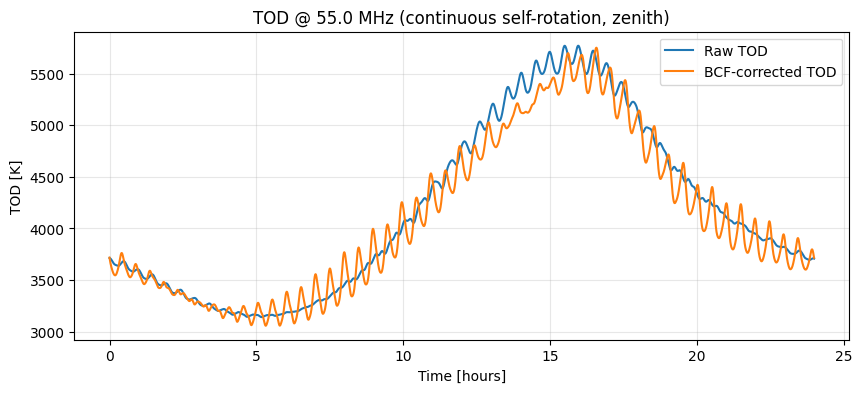

In [20]:
time_hours = time_list / 3600.0
plt.figure(figsize=(10, 4))
plt.plot(time_hours, tod, label="Raw TOD")
plt.plot(time_hours, tod_bcf_corr, label="BCF-corrected TOD")
plt.xlabel("Time [hours]")
plt.ylabel("TOD [K]")
plt.title(f"TOD @ {beam_freq_used:.1f} MHz (continuous self-rotation, zenith)")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

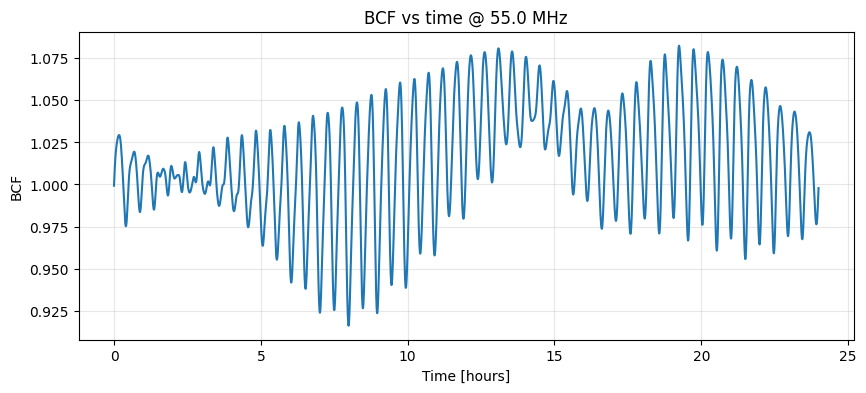

In [21]:
plt.figure(figsize=(10, 4))
plt.plot(time_hours, BCF)
plt.xlabel("Time [hours]")
plt.ylabel("BCF")
plt.title(f"BCF vs time @ {beam_freq_used:.1f} MHz")
plt.grid(alpha=0.3)
plt.show()